Import notebook 1 output


In [27]:


import os
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

from google.colab import files


# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/GridXAI_Diffusion_Notebook2"
)

ARTIFACT_DIR = (
    BASE_DIR /
    "Notebook1_Export"
)

OUTPUT_DIR = (
    BASE_DIR /
    "Results"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Upload Notebook 1 ZIP
# ------------------------------------------------------------

uploaded = files.upload()


zip_files = [

    name

    for name in uploaded.keys()

    if name.lower().endswith(".zip")

]


if not zip_files:

    raise FileNotFoundError(
        "Please upload the Notebook 1 output ZIP."
    )


ZIP_PATH = (
    Path("/content")
    /
    zip_files[0]
)


# ------------------------------------------------------------
# Extract
# ------------------------------------------------------------

if ARTIFACT_DIR.exists():

    shutil.rmtree(
        ARTIFACT_DIR
    )


ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as z:

    z.extractall(
        ARTIFACT_DIR
    )


# ------------------------------------------------------------
# Find artifacts
# ------------------------------------------------------------

def find_file(name):

    matches = list(
        ARTIFACT_DIR.rglob(name)
    )

    if not matches:

        raise FileNotFoundError(
            f"Required file not found: {name}"
        )

    return matches[0]


# ------------------------------------------------------------
# Load Notebook 1 data
# ------------------------------------------------------------

X_train = np.load(
    find_file("X_train.npy"),
    allow_pickle=True
)

X_validation = np.load(
    find_file("X_validation.npy"),
    allow_pickle=True
)

X_test = np.load(
    find_file("X_test.npy"),
    allow_pickle=True
)

y_train = np.load(
    find_file("y_train.npy"),
    allow_pickle=True
)

y_validation = np.load(
    find_file("y_validation.npy"),
    allow_pickle=True
)

y_test = np.load(
    find_file("y_test.npy"),
    allow_pickle=True
)


# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

train_metadata = pd.read_csv(
    find_file("train_metadata.csv")
)

validation_metadata = pd.read_csv(
    find_file("validation_metadata.csv")
)

test_metadata = pd.read_csv(
    find_file("test_metadata.csv")
)


# ------------------------------------------------------------
# Verify temporal data
# ------------------------------------------------------------

print("Notebook 1 artifact directory:")
print(ARTIFACT_DIR)

print()

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print()

print("Training labels:", y_train.shape)
print("Validation labels:", y_validation.shape)
print("Test labels:", y_test.shape)



Saving GridXAI_Diffusion_Notebook1_Output.zip to GridXAI_Diffusion_Notebook1_Output (3).zip
Notebook 1 artifact directory:
/content/GridXAI_Diffusion_Notebook2/Notebook1_Export

Training shape: (700, 35)
Validation shape: (150, 35)
Test shape: (150, 35)

Training labels: (700,)
Validation labels: (150,)
Test labels: (150,)


load files

In [28]:
# ============================================================
# NOTEBOOK 2 — CELL 2
# TEMPORAL WINDOW + DYNAMIC GRAPH PREPARATION
# ============================================================

import numpy as np
import pandas as pd
import torch


# ============================================================
# 1. SETTINGS
# ============================================================

TEMPORAL_WINDOW_SIZE = 10

FEATURE_DIMENSION = X_train.shape[-1]


# ============================================================
# 2. CONVERT NOTEBOOK 1 DATA INTO TEMPORAL WINDOWS
# ============================================================

def prepare_temporal_windows(
    X,
    y,
    window_size=10
):

    X = np.asarray(X)

    y = np.asarray(y)


    # --------------------------------------------------------
    # Case 1:
    # Notebook 1 already contains temporal sequences
    # --------------------------------------------------------

    if X.ndim == 3:

        if X.shape[1] != window_size:

            raise ValueError(

                "Existing temporal sequence has an "
                "unexpected window size.\n\n"

                f"Received: {X.shape}\n"

                f"Expected window size: {window_size}"

            )


        X_sequences = X.astype(
            np.float32
        )


        # Window-level target = final timestep

        if y.ndim == 1:

            y_sequences = y.astype(
                np.int64
            )


        elif y.ndim == 2:

            y_sequences = (

                y[:, -1]

                .astype(
                    np.int64
                )

            )


        else:

            raise ValueError(

                f"Unsupported label shape: {y.shape}"

            )


        return (
            X_sequences,
            y_sequences
        )



    if X.ndim == 2:

        n_observations = X.shape[0]

        n_features = X.shape[1]


        if n_observations < window_size:

            raise ValueError(

                "Not enough observations to construct "
                "a temporal window.\n\n"

                f"Observations: {n_observations}\n"

                f"Window size: {window_size}"

            )


        # ----------------------------------------------------
        # Number of overlapping windows
        # ----------------------------------------------------

        n_windows = (

            n_observations
            -
            window_size
            +
            1

        )


        X_sequences = np.stack(

            [

                X[
                    i :
                    i + window_size
                ]

                for i in range(
                    n_windows
                )

            ],

            axis=0

        ).astype(
            np.float32
        )


        # ----------------------------------------------------
        # Final timestep target
        # ----------------------------------------------------

        if y.ndim == 1:

            y_sequences = (

                y[
                    window_size - 1 :
                ]

                .astype(
                    np.int64
                )

            )


        elif y.ndim == 2:

            # If labels contain one label per timestep,
            # use the final timestep of each window.

            if y.shape[0] != n_observations:

                raise ValueError(

                    "Label length does not match "
                    "the number of raw observations.\n\n"

                    f"X observations: "
                    f"{n_observations}\n"

                    f"Y observations: "
                    f"{y.shape[0]}"

                )


            y_sequences = (

                y[
                    window_size - 1 :,
                    -1
                ]

                .astype(
                    np.int64
                )

            )


        else:

            raise ValueError(

                f"Unsupported label shape: {y.shape}"

            )


        return (
            X_sequences,
            y_sequences
        )


    raise ValueError(

        "Unsupported X dimension.\n\n"

        f"Received shape: {X.shape}\n"

        "Expected either:\n"

        "(samples, features)\n"

        "or\n"

        "(samples, temporal_window, features)"

    )


# ============================================================
# 3. PREPARE TRAINING WINDOWS
# ============================================================

X_train_sequences, y_train_sequences = (

    prepare_temporal_windows(

        X_train,

        y_train,

        TEMPORAL_WINDOW_SIZE

    )

)


# ============================================================
# 4. PREPARE VALIDATION WINDOWS
# ============================================================

X_validation_sequences, y_validation_sequences = (

    prepare_temporal_windows(

        X_validation,

        y_validation,

        TEMPORAL_WINDOW_SIZE

    )

)


# ============================================================
# 5. PREPARE TEST WINDOWS
# ============================================================

X_test_sequences, y_test_sequences = (

    prepare_temporal_windows(

        X_test,

        y_test,

        TEMPORAL_WINDOW_SIZE

    )

)


# ============================================================
# 6. FEATURE NAMES
# ============================================================

FEATURE_NAMES = [

    f"Feature_{i + 1}"

    for i in range(
        FEATURE_DIMENSION
    )

]


# ============================================================
# 7. VERIFY WINDOW ALIGNMENT
# ============================================================

assert (

    len(X_train_sequences)

    ==

    len(y_train_sequences)

)


assert (

    len(X_validation_sequences)

    ==

    len(y_validation_sequences)

)


assert (

    len(X_test_sequences)

    ==

    len(y_test_sequences)

)


# ============================================================
# 8. DISPLAY TEMPORAL DATASET SHAPES
# ============================================================

print("=" * 65)
print("NOTEBOOK 1 → NOTEBOOK 2 TEMPORAL WINDOW CONVERSION")
print("=" * 65)

print()

print(
    "Original training shape:",
    X_train.shape
)

print(
    "Original validation shape:",
    X_validation.shape
)

print(
    "Original test shape:",
    X_test.shape
)

print()

print(
    "Training sequences:",
    X_train_sequences.shape
)

print(
    "Validation sequences:",
    X_validation_sequences.shape
)

print(
    "Test sequences:",
    X_test_sequences.shape
)

print()

print(
    "Training window labels:",
    y_train_sequences.shape
)

print(
    "Validation window labels:",
    y_validation_sequences.shape
)

print(
    "Test window labels:",
    y_test_sequences.shape
)


# ============================================================
# 9. CLASS DISTRIBUTION
# ============================================================

class_distribution = pd.DataFrame({

    "Dataset": [

        "Training",

        "Validation",

        "Test"

    ],

    "Benign": [

        int(
            np.sum(
                y_train_sequences == 0
            )
        ),

        int(
            np.sum(
                y_validation_sequences == 0
            )
        ),

        int(
            np.sum(
                y_test_sequences == 0
            )
        )

    ],

    "Attack": [

        int(
            np.sum(
                y_train_sequences == 1
            )
        ),

        int(
            np.sum(
                y_validation_sequences == 1
            )
        ),

        int(
            np.sum(
                y_test_sequences == 1
            )
        )

    ]

})


display(
    class_distribution
)


# ============================================================
# 10. BUILD DYNAMIC SIMILARITY GRAPH
# ============================================================

def build_dynamic_graphs(

    X,

    threshold=0.75

):

    X = np.asarray(
        X,
        dtype=np.float32
    )


    n_samples = X.shape[0]

    n_nodes = X.shape[1]


    adjacency = np.zeros(

        (
            n_samples,
            n_nodes,
            n_nodes
        ),

        dtype=np.float32

    )


    for sample_index in range(
        n_samples
    ):

        window = X[
            sample_index
        ]


        # ----------------------------------------------------
        # Normalize each node feature vector
        # ----------------------------------------------------

        norms = np.linalg.norm(

            window,

            axis=1,

            keepdims=True

        )


        norms[
            norms == 0
        ] = 1.0


        normalized = (

            window
            /
            norms

        )


        # ----------------------------------------------------
        # Cosine similarity
        # ----------------------------------------------------

        similarity = (

            normalized
            @
            normalized.T

        )


        # ----------------------------------------------------
        # Dynamic adjacency
        # ----------------------------------------------------

        graph = (

            similarity >= threshold

        ).astype(
            np.float32
        )


        # Self connections

        np.fill_diagonal(

            graph,

            1.0

        )


        adjacency[
            sample_index
        ] = graph


    return adjacency


# ============================================================
# 11. CREATE TRAIN / VALIDATION / TEST GRAPHS
# ============================================================

A_train = build_dynamic_graphs(

    X_train_sequences,

    threshold=0.75

)


A_validation = build_dynamic_graphs(

    X_validation_sequences,

    threshold=0.75

)


A_test = build_dynamic_graphs(

    X_test_sequences,

    threshold=0.75

)


# ============================================================
# 12. GRAPH STATISTICS
# ============================================================

def graph_statistics(

    adjacency

):

    n_nodes = adjacency.shape[1]

    possible_edges = (

        n_nodes
        *
        (n_nodes - 1)

    )


    edge_counts = (

        adjacency.sum(
            axis=(1, 2)
        )

        -

        n_nodes

    )


    density = (

        edge_counts
        /
        possible_edges

    )


    return {

        "Mean edges":
            float(
                edge_counts.mean()
            ),

        "Median edges":
            float(
                np.median(
                    edge_counts
                )
            ),

        "Mean density":
            float(
                density.mean()
            ),

        "Maximum density":
            float(
                density.max()
            )

    }


train_graph_stats = graph_statistics(
    A_train
)

validation_graph_stats = graph_statistics(
    A_validation
)

test_graph_stats = graph_statistics(
    A_test
)


graph_statistics_table = pd.DataFrame({

    "Dataset": [

        "Training",

        "Validation",

        "Test"

    ],

    "Mean edges": [

        train_graph_stats[
            "Mean edges"
        ],

        validation_graph_stats[
            "Mean edges"
        ],

        test_graph_stats[
            "Mean edges"
        ]

    ],

    "Median edges": [

        train_graph_stats[
            "Median edges"
        ],

        validation_graph_stats[
            "Median edges"
        ],

        test_graph_stats[
            "Median edges"
        ]

    ],

    "Mean density": [

        train_graph_stats[
            "Mean density"
        ],

        validation_graph_stats[
            "Mean density"
        ],

        test_graph_stats[
            "Mean density"
        ]

    ],

    "Maximum density": [

        train_graph_stats[
            "Maximum density"
        ],

        validation_graph_stats[
            "Maximum density"
        ],

        test_graph_stats[
            "Maximum density"
        ]

    ]

})


display(
    graph_statistics_table
)


# ============================================================
# 13. CONVERT TO PYTORCH
# ============================================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)


X_train_tensor = torch.tensor(

    X_train_sequences,

    dtype=torch.float32,

    device=device

)


X_validation_tensor = torch.tensor(

    X_validation_sequences,

    dtype=torch.float32,

    device=device

)


X_test_tensor = torch.tensor(

    X_test_sequences,

    dtype=torch.float32,

    device=device

)


A_train_tensor = torch.tensor(

    A_train,

    dtype=torch.float32,

    device=device

)


A_validation_tensor = torch.tensor(

    A_validation,

    dtype=torch.float32,

    device=device

)


A_test_tensor = torch.tensor(

    A_test,

    dtype=torch.float32,

    device=device

)


y_train_tensor = torch.tensor(

    y_train_sequences,

    dtype=torch.float32,

    device=device

)


y_validation_tensor = torch.tensor(

    y_validation_sequences,

    dtype=torch.float32,

    device=device

)


y_test_tensor = torch.tensor(

    y_test_sequences,

    dtype=torch.float32,

    device=device

)


# ============================================================
# 14. SAVE CELL 2 TABLES
# ============================================================

class_distribution.to_csv(

    OUTPUT_DIR /
    "cell2_class_distribution.csv",

    index=False

)


graph_statistics_table.to_csv(

    OUTPUT_DIR /
    "cell2_graph_statistics.csv",

    index=False

)


# ============================================================
# 15. FINAL VERIFICATION
# ============================================================

print()
print("=" * 65)
print("CELL 2 COMPLETE")
print("=" * 65)

print()

print(
    "Device:",
    device
)

print()

print(
    "Temporal window:",
    TEMPORAL_WINDOW_SIZE
)

print(
    "Feature dimension:",
    FEATURE_DIMENSION
)

print()

print(
    "Training:",
    X_train_sequences.shape
)

print(
    "Validation:",
    X_validation_sequences.shape
)

print(
    "Test:",
    X_test_sequences.shape
)

print()

print(
    "Training graph:",
    A_train.shape
)

print(
    "Validation graph:",
    A_validation.shape
)

print(
    "Test graph:",
    A_test.shape
)

print()

print(
    "Prediction target: Final timestep"
)

print()

print(
    "Cell 2 completed using ONLY Notebook 1 exported data."
)

print(
    "Proceed to Cell 3."
)

print("=" * 65)

NOTEBOOK 1 → NOTEBOOK 2 TEMPORAL WINDOW CONVERSION

Original training shape: (700, 35)
Original validation shape: (150, 35)
Original test shape: (150, 35)

Training sequences: (691, 10, 35)
Validation sequences: (141, 10, 35)
Test sequences: (141, 10, 35)

Training window labels: (691,)
Validation window labels: (141,)
Test window labels: (141,)


,Dataset,Benign,Attack
0,Training,331,360
1,Validation,78,63
2,Test,66,75


,Dataset,Mean edges,Median edges,Mean density,Maximum density
0,Training,2.179450,2.0,0.024216,0.111111
1,Validation,1.659575,2.0,0.018440,0.111111
2,Test,1.319149,2.0,0.014657,0.066667



CELL 2 COMPLETE

Device: cuda

Temporal window: 10
Feature dimension: 35

Training: (691, 10, 35)
Validation: (141, 10, 35)
Test: (141, 10, 35)

Training graph: (691, 10, 10)
Validation graph: (141, 10, 10)
Test graph: (141, 10, 10)

Prediction target: Final timestep

Cell 2 completed using ONLY Notebook 1 exported data.
Proceed to Cell 3.


dynamic graph for a representative training temporal window

CELL 3 — DATASET EXPLORATION

Training sequence shape: (691, 10, 35)
Training label shape: (691,)
Temporal window: 10
Feature dimension: 35

Window-level target verified.
Prediction target: Final timestep
Number of training windows: 691


,Class,Count,Percentage
0,Benign,331,47.901592
1,Attack,360,52.098408


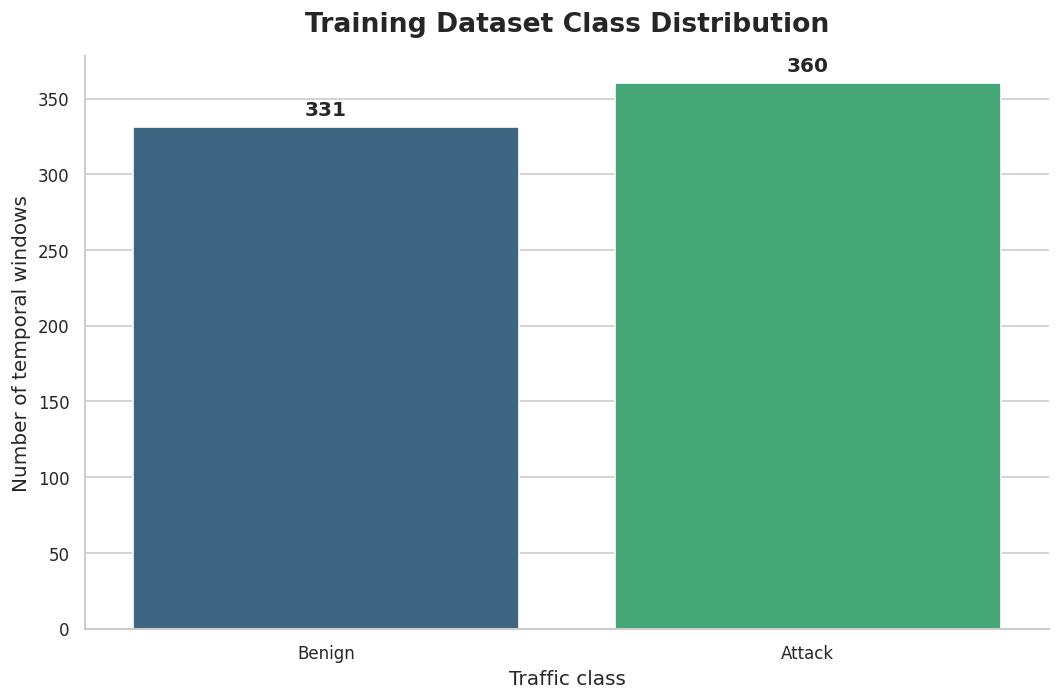

In [29]:


# ------------------------------------------------------------
# 1. IMPORTS
# ------------------------------------------------------------

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 2. SEABORN PRESENTATION SETTINGS
# ------------------------------------------------------------

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({

    "figure.dpi": 120,

    "savefig.dpi": 300,

    "axes.titlesize": 16,

    "axes.labelsize": 12,

    "xtick.labelsize": 10,

    "ytick.labelsize": 10,

    "legend.fontsize": 10

})


# ------------------------------------------------------------
# 3. VERIFY CELL 2
# ------------------------------------------------------------

required_variables = [

    "X_train_sequences",

    "y_train_sequences",

    "FEATURE_NAMES",

    "TEMPORAL_WINDOW_SIZE",

    "FEATURE_DIMENSION",

    "OUTPUT_DIR"

]


missing_variables = [

    variable

    for variable in required_variables

    if variable not in globals()

]


if missing_variables:

    raise RuntimeError(

        "Cell 2 must be executed successfully first.\n\n"

        "Missing variables:\n"

        +
        "\n".join(
            missing_variables
        )

    )


# ------------------------------------------------------------
# 4. CREATE FIGURE DIRECTORY
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    OUTPUT_DIR
)

FIGURE_DIR = (

    OUTPUT_DIR
    /
    "figures"

)

FIGURE_DIR.mkdir(

    parents=True,

    exist_ok=True

)


# ============================================================
# 5. VERIFY TRAINING SEQUENCE
# ============================================================

print("=" * 60)
print("CELL 3 — DATASET EXPLORATION")
print("=" * 60)

print()

print(
    "Training sequence shape:",
    X_train_sequences.shape
)

print(
    "Training label shape:",
    y_train_sequences.shape
)

print(
    "Temporal window:",
    TEMPORAL_WINDOW_SIZE
)

print(
    "Feature dimension:",
    FEATURE_DIMENSION
)


# ------------------------------------------------------------
# Check X shape
# ------------------------------------------------------------

if X_train_sequences.ndim != 3:

    raise ValueError(

        "X_train_sequences must have shape:\n"

        "(samples, temporal_window, features)\n\n"

        f"Received: {X_train_sequences.shape}"

    )


if X_train_sequences.shape[1] != TEMPORAL_WINDOW_SIZE:

    raise ValueError(

        "Temporal dimension does not match "
        "TEMPORAL_WINDOW_SIZE.\n\n"

        f"X shape: {X_train_sequences.shape}\n"

        f"Expected temporal window: "
        f"{TEMPORAL_WINDOW_SIZE}"

    )


if X_train_sequences.shape[2] != FEATURE_DIMENSION:

    raise ValueError(

        "Feature dimension does not match "
        "FEATURE_DIMENSION.\n\n"

        f"X shape: {X_train_sequences.shape}\n"

        f"Expected features: "
        f"{FEATURE_DIMENSION}"

    )



if y_train_sequences.ndim == 1:

    y_train_window = (

        np.asarray(
            y_train_sequences
        )
        .astype(int)
        .reshape(-1)

    )


elif y_train_sequences.ndim == 2:

    if (

        y_train_sequences.shape[0]
        !=
        X_train_sequences.shape[0]

    ):

        raise ValueError(

            "Number of label windows does not match "
            "number of training windows.\n\n"

            f"X windows: "
            f"{X_train_sequences.shape[0]}\n"

            f"Label windows: "
            f"{y_train_sequences.shape[0]}"

        )


    if (

        y_train_sequences.shape[1]
        <
        1

    ):

        raise ValueError(
            "y_train_sequences contains no temporal labels."
        )


    # FINAL TIMESTEP TARGET

    y_train_window = (

        np.asarray(
            y_train_sequences[:, -1]
        )
        .astype(int)
        .reshape(-1)

    )


else:

    raise ValueError(

        "Unsupported y_train_sequences shape: "

        f"{y_train_sequences.shape}"

    )


# ------------------------------------------------------------
# Validate labels
# ------------------------------------------------------------

unique_labels = np.unique(
    y_train_window
)


invalid_labels = [

    value

    for value in unique_labels

    if value not in [0, 1]

]


if invalid_labels:

    raise ValueError(

        "Training labels must contain only "
        "0 and 1.\n\n"

        f"Found: {unique_labels}"

    )


if len(y_train_window) != X_train_sequences.shape[0]:

    raise ValueError(

        "Window-level label count does not match "
        "training sequence count.\n\n"

        f"X windows: "
        f"{X_train_sequences.shape[0]}\n"

        f"y windows: "
        f"{len(y_train_window)}"

    )


print()

print(
    "Window-level target verified."
)

print(
    "Prediction target: Final timestep"
)

print(
    "Number of training windows:",
    len(y_train_window)
)


# ============================================================
# 7. PREPARE DATA FOR VISUALIZATION
# ============================================================

# Flatten X ONLY for visualization.
#
# This does NOT change the model training data.
#
# Each temporal observation receives the label of
# its corresponding window so that class-wise feature
# distributions can be visualized.


X_train_flat = (

    X_train_sequences

    .reshape(

        -1,

        FEATURE_DIMENSION

    )

)


y_train_flat = np.repeat(

    y_train_window,

    TEMPORAL_WINDOW_SIZE

)


if len(X_train_flat) != len(y_train_flat):

    raise RuntimeError(

        "Visualization data alignment failed.\n\n"

        f"X observations: "
        f"{len(X_train_flat)}\n"

        f"Expanded labels: "
        f"{len(y_train_flat)}"

    )


train_dataframe = pd.DataFrame(

    X_train_flat,

    columns=FEATURE_NAMES

)


train_dataframe["Class"] = np.where(

    y_train_flat == 1,

    "Attack",

    "Benign"

)


# ============================================================
# VISUALIZATION 1
# CLASS DISTRIBUTION
# ============================================================

class_counts = pd.DataFrame({

    "Class": [

        "Benign",

        "Attack"

    ],

    "Count": [

        int(
            np.sum(
                y_train_window == 0
            )
        ),

        int(
            np.sum(
                y_train_window == 1
            )
        )

    ]

})


class_counts["Percentage"] = (

    class_counts["Count"]

    /

    class_counts["Count"].sum()

    *

    100

)


display(
    class_counts
)


plt.figure(

    figsize=(9, 6)

)


ax = sns.barplot(

    data=class_counts,

    x="Class",

    y="Count",

    hue="Class",

    palette="viridis",

    legend=False

)


for container in ax.containers:

    ax.bar_label(

        container,

        fmt="%d",

        padding=5,

        fontsize=12,

        fontweight="bold"

    )


plt.title(

    "Training Dataset Class Distribution",

    fontweight="bold",

    pad=15

)


plt.xlabel(
    "Traffic class"
)


plt.ylabel(
    "Number of temporal windows"
)


sns.despine()


plt.tight_layout()


plt.savefig(

    FIGURE_DIR
    /
    "01_class_distribution.png",

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# ============================================================
# VISUALIZATION 2
# ATTACK VS BENIGN FEATURE DIFFERENCE
# ============================================================

# Calculate class-wise feature means using the same
# window-level target as the model.


class_feature_means = (

    train_dataframe

    .groupby(
        "Class"
    )[FEATURE_NAMES]

    .mean()

)


# Difference between Attack and Benign means.


feature_difference = (

    class_feature_means.loc[
        "Attack"
    ]

    -

    class_feature_means.loc[
        "Benign"
    ]

)


# Select the 15 features with the largest
# absolute class separation.


top_feature_count = min(

    15,

    FEATURE_DIMENSION

)


top_features = (

    feature_difference

    .abs()

    .sort_values(

        ascending=False

    )

    .head(
        top_feature_count
    )

    .index

)


# ------------------------------------------------------------
# Build plotting dataframe
# ------------------------------------------------------------

feature_profile = (

    class_feature_means[
        top_features
    ]

    .T

    .reset_index()

)


feature_profile = (

    feature_profile

    .rename(

        columns={

            "index":
            "Feature"

        }

    )

)


feature_profile_long = (

    feature_profile

    .melt(

        id_vars="Feature",

        var_name="Class",

        value_name="Mean"

    )

)






# ============================================================
# 8. SAVE TABLES
# ============================================================

class_counts.to_csv(

    OUTPUT_DIR
    /
    "class_distribution_table.csv",

    index=False

)


temporal_dataframe.to_csv(

    OUTPUT_DIR
    /
    "temporal_feature_evolution.csv",

    index=True

)




Defining Model

In [30]:
# ============================================================
# NOTEBOOK 2 — CELL 4
# MODEL INPUT PREPARATION + DYNAMIC GRAPH REPRESENTATION
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"

)

print(
    "Device:",
    device
)


# ============================================================
# 3. MODEL DIMENSIONS
# ============================================================

INPUT_DIM = FEATURE_DIMENSION

NUM_NODES = TEMPORAL_WINDOW_SIZE

HIDDEN_DIM = 64

NUM_HEADS = 4

NUM_TRANSFORMER_LAYERS = 2

DROPOUT = 0.20


# ============================================================
# 4. NORMALIZE FEATURES USING TRAINING DATA ONLY
# ============================================================

train_mean = X_train_sequences.mean(
    axis=(0, 1),
    keepdims=True
)

train_std = X_train_sequences.std(
    axis=(0, 1),
    keepdims=True
)


train_std[
    train_std < 1e-8
] = 1.0


X_train_normalized = (

    X_train_sequences
    -
    train_mean

) / train_std


X_validation_normalized = (

    X_validation_sequences
    -
    train_mean

) / train_std


X_test_normalized = (

    X_test_sequences
    -
    train_mean

) / train_std


# ============================================================
# 5. REBUILD DYNAMIC GRAPHS USING NORMALIZED FEATURES
# ============================================================

def create_dynamic_adjacency(

    X,
    threshold=0.75

):

    X = np.asarray(
        X,
        dtype=np.float32
    )

    n_samples = X.shape[0]

    n_nodes = X.shape[1]

    adjacency = np.zeros(

        (
            n_samples,
            n_nodes,
            n_nodes
        ),

        dtype=np.float32

    )


    for i in range(
        n_samples
    ):

        node_features = X[i]


        norms = np.linalg.norm(

            node_features,

            axis=1,

            keepdims=True

        )


        norms[
            norms < 1e-8
        ] = 1.0


        normalized_nodes = (

            node_features
            /
            norms

        )


        similarity = (

            normalized_nodes
            @
            normalized_nodes.T

        )


        graph = (

            similarity >= threshold

        ).astype(
            np.float32
        )


        # Self-loops

        np.fill_diagonal(

            graph,

            1.0

        )


        adjacency[i] = graph


    return adjacency


A_train = create_dynamic_adjacency(

    X_train_normalized,

    threshold=0.75

)


A_validation = create_dynamic_adjacency(

    X_validation_normalized,

    threshold=0.75

)


A_test = create_dynamic_adjacency(

    X_test_normalized,

    threshold=0.75

)


# ============================================================
# 6. CONVERT TO TORCH
# ============================================================

X_train_tensor = torch.tensor(

    X_train_normalized,

    dtype=torch.float32,

    device=device

)

X_validation_tensor = torch.tensor(

    X_validation_normalized,

    dtype=torch.float32,

    device=device

)

X_test_tensor = torch.tensor(

    X_test_normalized,

    dtype=torch.float32,

    device=device

)


A_train_tensor = torch.tensor(

    A_train,

    dtype=torch.float32,

    device=device

)

A_validation_tensor = torch.tensor(

    A_validation,

    dtype=torch.float32,

    device=device

)

A_test_tensor = torch.tensor(

    A_test,

    dtype=torch.float32,

    device=device

)


y_train_tensor = torch.tensor(

    y_train_sequences,

    dtype=torch.float32,

    device=device

)

y_validation_tensor = torch.tensor(

    y_validation_sequences,

    dtype=torch.float32,

    device=device

)

y_test_tensor = torch.tensor(

    y_test_sequences,

    dtype=torch.float32,

    device=device

)


# ============================================================
# 7. VERIFY MODEL INPUTS
# ============================================================

print()
print("=" * 65)
print("MODEL INPUT VERIFICATION")
print("=" * 65)

print()

print(
    "Training X:",
    tuple(X_train_tensor.shape)
)

print(
    "Validation X:",
    tuple(X_validation_tensor.shape)
)

print(
    "Test X:",
    tuple(X_test_tensor.shape)
)

print()

print(
    "Training graph:",
    tuple(A_train_tensor.shape)
)

print(
    "Validation graph:",
    tuple(A_validation_tensor.shape)
)

print(
    "Test graph:",
    tuple(A_test_tensor.shape)
)

print()

print(
    "Training labels:",
    tuple(y_train_tensor.shape)
)

print(
    "Validation labels:",
    tuple(y_validation_tensor.shape)
)

print(
    "Test labels:",
    tuple(y_test_tensor.shape)
)


# ============================================================
# 8. GRAPH STATISTICS
# ============================================================

def calculate_graph_statistics(

    adjacency

):

    n_nodes = adjacency.shape[1]

    edge_counts = (

        adjacency.sum(
            axis=(1, 2)
        )

        -
        n_nodes

    )

    possible_edges = (

        n_nodes
        *
        (n_nodes - 1)

    )

    density = (

        edge_counts
        /
        possible_edges

    )


    return {

        "Mean edges":
            float(
                edge_counts.mean()
            ),

        "Median edges":
            float(
                np.median(
                    edge_counts
                )
            ),

        "Mean density":
            float(
                density.mean()
            ),

        "Maximum density":
            float(
                density.max()
            )

    }


train_stats = calculate_graph_statistics(
    A_train
)

validation_stats = calculate_graph_statistics(
    A_validation
)

test_stats = calculate_graph_statistics(
    A_test
)


graph_summary = pd.DataFrame({

    "Statistic": [

        "Training mean edges",

        "Training median edges",

        "Training mean density",

        "Training maximum density",

        "Validation mean edges",

        "Test mean edges"

    ],

    "Value": [

        train_stats["Mean edges"],

        train_stats["Median edges"],

        train_stats["Mean density"],

        train_stats["Maximum density"],

        validation_stats["Mean edges"],

        test_stats["Mean edges"]

    ]

})


display(
    graph_summary
)


# ============================================================
# 9. SAVE MODEL INPUT SUMMARY
# ============================================================

model_input_summary = pd.DataFrame({

    "component": [

        "Input feature dimension",

        "Temporal window",

        "Graph nodes",

        "Hidden dimension",

        "Transformer heads",

        "Transformer layers",

        "Dropout",

        "Graph similarity threshold",

        "Device"

    ],

    "value": [

        INPUT_DIM,

        NUM_NODES,

        NUM_NODES,

        HIDDEN_DIM,

        NUM_HEADS,

        NUM_TRANSFORMER_LAYERS,

        DROPOUT,

        0.75,

        str(device)

    ]

})


display(
    model_input_summary
)


model_input_summary.to_csv(

    OUTPUT_DIR /
    "model_input_summary.csv",

    index=False

)


graph_summary.to_csv(

    OUTPUT_DIR /
    "dynamic_graph_summary.csv",

    index=False

)




Device: cuda

MODEL INPUT VERIFICATION

Training X: (691, 10, 35)
Validation X: (141, 10, 35)
Test X: (141, 10, 35)

Training graph: (691, 10, 10)
Validation graph: (141, 10, 10)
Test graph: (141, 10, 10)

Training labels: (691,)
Validation labels: (141,)
Test labels: (141,)


,Statistic,Value
0,Training mean edges,0.0
1,Training median edges,0.0
2,Training mean density,0.0
3,Training maximum density,0.0
4,Validation mean edges,0.0
5,Test mean edges,0.0


,component,value
0,Input feature dimension,35
1,Temporal window,10
2,Graph nodes,10
3,Hidden dimension,64
4,Transformer heads,4
5,Transformer layers,2
6,Dropout,0.2
7,Graph similarity threshold,0.75
8,Device,cuda


Model training + NT-Xent + training curves

In [31]:
# ============================================================
# NOTEBOOK 2 — CELL 5
# GRIDXAI SPATIO-TEMPORAL MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# 1. GRAPH ATTENTION
# ============================================================

class GraphAttention(
    nn.Module
):

    def __init__(
        self,
        hidden_dim,
        dropout=0.20
    ):

        super().__init__()

        self.q = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False
        )

        self.k = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False
        )

        self.v = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.norm = nn.LayerNorm(
            hidden_dim
        )


    def forward(
        self,
        x,
        adjacency,
        return_attention=False
    ):

        # x:
        # [batch, nodes, hidden]

        q = self.q(x)

        k = self.k(x)

        v = self.v(x)


        # ----------------------------------------------------
        # Attention scores
        # ----------------------------------------------------

        scores = torch.matmul(

            q,

            k.transpose(
                -2,
                -1
            )

        )


        scores = (

            scores
            /
            np.sqrt(
                q.size(-1)
            )

        )


        # ----------------------------------------------------
        # Apply dynamic graph mask
        # ----------------------------------------------------

        graph_mask = (

            adjacency > 0

        )


        scores = scores.masked_fill(

            ~graph_mask,

            -1e9

        )


        attention = F.softmax(

            scores,

            dim=-1

        )


        attention = self.dropout(
            attention
        )


        # ----------------------------------------------------
        # Message aggregation
        # ----------------------------------------------------

        output = torch.matmul(

            attention,

            v

        )


        output = self.norm(

            output + x

        )


        if return_attention:

            return (
                output,
                attention
            )


        return output


# ============================================================
# 2. GRIDXAI SPATIO-TEMPORAL MODEL
# ============================================================

class GridXAI_ST_Model(
    nn.Module
):

    def __init__(

        self,

        input_dim,

        hidden_dim=64,

        num_heads=4,

        num_layers=2,

        dropout=0.20

    ):

        super().__init__()


        # ----------------------------------------------------
        # Feature projection
        # ----------------------------------------------------

        self.feature_projection = nn.Sequential(

            nn.Linear(

                input_dim,

                hidden_dim

            ),

            nn.GELU(),

            nn.LayerNorm(

                hidden_dim

            )

        )


        # ----------------------------------------------------
        # Graph attention
        # ----------------------------------------------------

        self.graph_attention = GraphAttention(

            hidden_dim=hidden_dim,

            dropout=dropout

        )


        # ----------------------------------------------------
        # Spatial fusion
        # ----------------------------------------------------

        self.fusion = nn.Sequential(

            nn.Linear(

                hidden_dim * 2,

                hidden_dim

            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.LayerNorm(

                hidden_dim

            )

        )


        # ----------------------------------------------------
        # Temporal Transformer
        # ----------------------------------------------------

        encoder_layer = (

            nn.TransformerEncoderLayer(

                d_model=hidden_dim,

                nhead=num_heads,

                dim_feedforward=hidden_dim * 2,

                dropout=dropout,

                activation="gelu",

                batch_first=True,

                norm_first=False

            )

        )


        self.temporal_transformer = (

            nn.TransformerEncoder(

                encoder_layer,

                num_layers=num_layers

            )

        )


        self.norm = nn.LayerNorm(
            hidden_dim
        )


        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(

                hidden_dim,

                hidden_dim // 2

            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(

                hidden_dim // 2,

                1

            )

        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(

        self,

        x,

        adjacency,

        return_attention=False

    ):

        # ----------------------------------------------------
        # Input:
        #
        # [batch, temporal_window, features]
        #
        # Each temporal position is treated as a graph node.
        # ----------------------------------------------------

        projected = self.feature_projection(
            x
        )


        # ----------------------------------------------------
        # Dynamic graph attention
        # ----------------------------------------------------

        graph_output, attention = (

            self.graph_attention(

                projected,

                adjacency,

                return_attention=True

            )

        )


        # ----------------------------------------------------
        # Spatial fusion
        # ----------------------------------------------------

        fused = self.fusion(

            torch.cat(

                [

                    projected,

                    graph_output

                ],

                dim=-1

            )

        )


        # ----------------------------------------------------
        # Temporal Transformer
        # ----------------------------------------------------

        temporal_output = (

            self.temporal_transformer(

                fused

            )

        )


        temporal_output = self.norm(

            temporal_output

        )


        # ----------------------------------------------------
        # Final timestep representation
        # ----------------------------------------------------

        representation = (

            temporal_output[:, -1, :]

        )


        # ----------------------------------------------------
        # Classification
        # ----------------------------------------------------

        logits = self.classifier(

            representation

        ).squeeze(-1)


        if return_attention:

            return (

                logits,

                representation,

                attention,

                temporal_output

            )


        return (

            logits,

            representation

        )


# ============================================================
# 3. CONTRASTIVE LOSS
# ============================================================

def contrastive_loss(

    representations,

    labels,

    temperature=0.5

):

    if representations.size(0) < 2:

        return torch.tensor(

            0.0,

            device=representations.device

        )


    z = F.normalize(

        representations,

        p=2,

        dim=1

    )


    similarity = (

        torch.matmul(

            z,

            z.T

        )

        /

        temperature

    )


    labels = labels.long()


    positive_mask = (

        labels.unsqueeze(0)

        ==

        labels.unsqueeze(1)

    )


    diagonal_mask = torch.eye(

        labels.size(0),

        dtype=torch.bool,

        device=labels.device

    )


    positive_mask = (

        positive_mask
        &
        ~diagonal_mask

    )


    logits_mask = (

        ~diagonal_mask

    )


    similarity = similarity.masked_fill(

        ~logits_mask,

        -1e9

    )


    log_prob = (

        similarity
        -
        torch.logsumexp(

            similarity,

            dim=1,

            keepdim=True

        )

    )


    positive_count = (

        positive_mask.sum(
            dim=1
        )

    )


    valid = (
        positive_count > 0
    )


    if valid.sum() == 0:

        return torch.tensor(

            0.0,

            device=representations.device

        )


    mean_log_prob_pos = (

        (

            log_prob
            *
            positive_mask.float()

        ).sum(
            dim=1
        )

        /

        positive_count.clamp(
            min=1
        )

    )


    return -mean_log_prob_pos[
        valid
    ].mean()


# ============================================================
# 4. CREATE MODEL
# ============================================================

model = GridXAI_ST_Model(

    input_dim=INPUT_DIM,

    hidden_dim=HIDDEN_DIM,

    num_heads=NUM_HEADS,

    num_layers=NUM_TRANSFORMER_LAYERS,

    dropout=DROPOUT

).to(
    device
)


# ============================================================
# 5. PARAMETER COUNT
# ============================================================

trainable_parameters = sum(

    parameter.numel()

    for parameter in model.parameters()

    if parameter.requires_grad

)


# ============================================================
# 6. MODEL SUMMARY
# ============================================================

print("=" * 65)
print("GRIDXAI SPATIO-TEMPORAL MODEL")
print("=" * 65)

print()

print(model)

print()

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print()

print(
    "Input dimension:",
    INPUT_DIM
)

print(
    "Temporal window:",
    NUM_NODES
)

print(
    "Hidden dimension:",
    HIDDEN_DIM
)

print(
    "Transformer heads:",
    NUM_HEADS
)

print(
    "Transformer layers:",
    NUM_TRANSFORMER_LAYERS
)

print(
    "Dropout:",
    DROPOUT
)

print()

print(
    "Architecture:"
)

print(
    "Dynamic Graph"
    " → Graph Attention"
    " → Spatial Fusion"
    " → Temporal Transformer"
    " → Contrastive Representation"
    " → Classifier"
)


# ============================================================
# 7. MODEL INPUT TEST
# ============================================================

with torch.no_grad():

    sample_x = X_train_tensor[:2]

    sample_a = A_train_tensor[:2]

    sample_output = model(

        sample_x,

        sample_a

    )


print()

print(
    "Forward-pass logits shape:",
    tuple(
        sample_output[0].shape
    )
)

print(
    "Representation shape:",
    tuple(
        sample_output[1].shape
    )
)


# ============================================================
# 8. SAVE ARCHITECTURE SUMMARY
# ============================================================

architecture_summary = pd.DataFrame({

    "component": [

        "Input feature dimension",

        "Temporal window",

        "Graph nodes",

        "Hidden dimension",

        "Graph attention",

        "Transformer heads",

        "Transformer layers",

        "Dropout",

        "Contrastive learning",

        "Trainable parameters"

    ],

    "value": [

        INPUT_DIM,

        NUM_NODES,

        NUM_NODES,

        HIDDEN_DIM,

        "Implemented",

        NUM_HEADS,

        NUM_TRANSFORMER_LAYERS,

        DROPOUT,

        "Implemented",

        trainable_parameters

    ]

})


display(
    architecture_summary
)


architecture_summary.to_csv(

    OUTPUT_DIR /
    "architecture_summary.csv",

    index=False

)


# ============================================================
# FINAL
# ============================================================

print()

print("=" * 65)
print("CELL 5 COMPLETE")
print("=" * 65)

print()

print(
    "Model initialized successfully."
)

print(
    "Forward pass verified successfully."
)

print(
    "Ready for Cell 6 — training + validation + test evaluation."
)

print("=" * 65)

GRIDXAI SPATIO-TEMPORAL MODEL

GridXAI_ST_Model(
  (feature_projection): Sequential(
    (0): Linear(in_features=35, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (graph_attention): GraphAttention(
    (q): Linear(in_features=64, out_features=64, bias=False)
    (k): Linear(in_features=64, out_features=64, bias=False)
    (v): Linear(in_features=64, out_features=64, bias=False)
    (dropout): Dropout(p=0.2, inplace=False)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (fusion): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (temporal_transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuanti

,component,value
0,Input feature dimension,35
1,Temporal window,10
2,Graph nodes,10
3,Hidden dimension,64
4,Graph attention,Implemented
5,Transformer heads,4
6,Transformer layers,2
7,Dropout,0.2
8,Contrastive learning,Implemented
9,Trainable parameters,92417



CELL 5 COMPLETE

Model initialized successfully.
Forward pass verified successfully.
Ready for Cell 6 — training + validation + test evaluation.


model evaluation

Positive class weight: 0.9194444417953491

GRIDXAI SPATIO-TEMPORAL TRAINING

Epoch 001/100 | Loss: 0.68085 | Cls: 0.67249 | Con: 4.18094 | Val Acc: 0.4539 | Val F1: 0.4031 | Val AUC: 0.4544
Epoch 010/100 | Loss: 0.36703 | Cls: 0.35892 | Con: 4.05769 | Val Acc: 0.4752 | Val F1: 0.4308 | Val AUC: 0.4589
Epoch 020/100 | Loss: 0.18255 | Cls: 0.17485 | Con: 3.85021 | Val Acc: 0.4468 | Val F1: 0.4658 | Val AUC: 0.4392

Early stopping at epoch 23


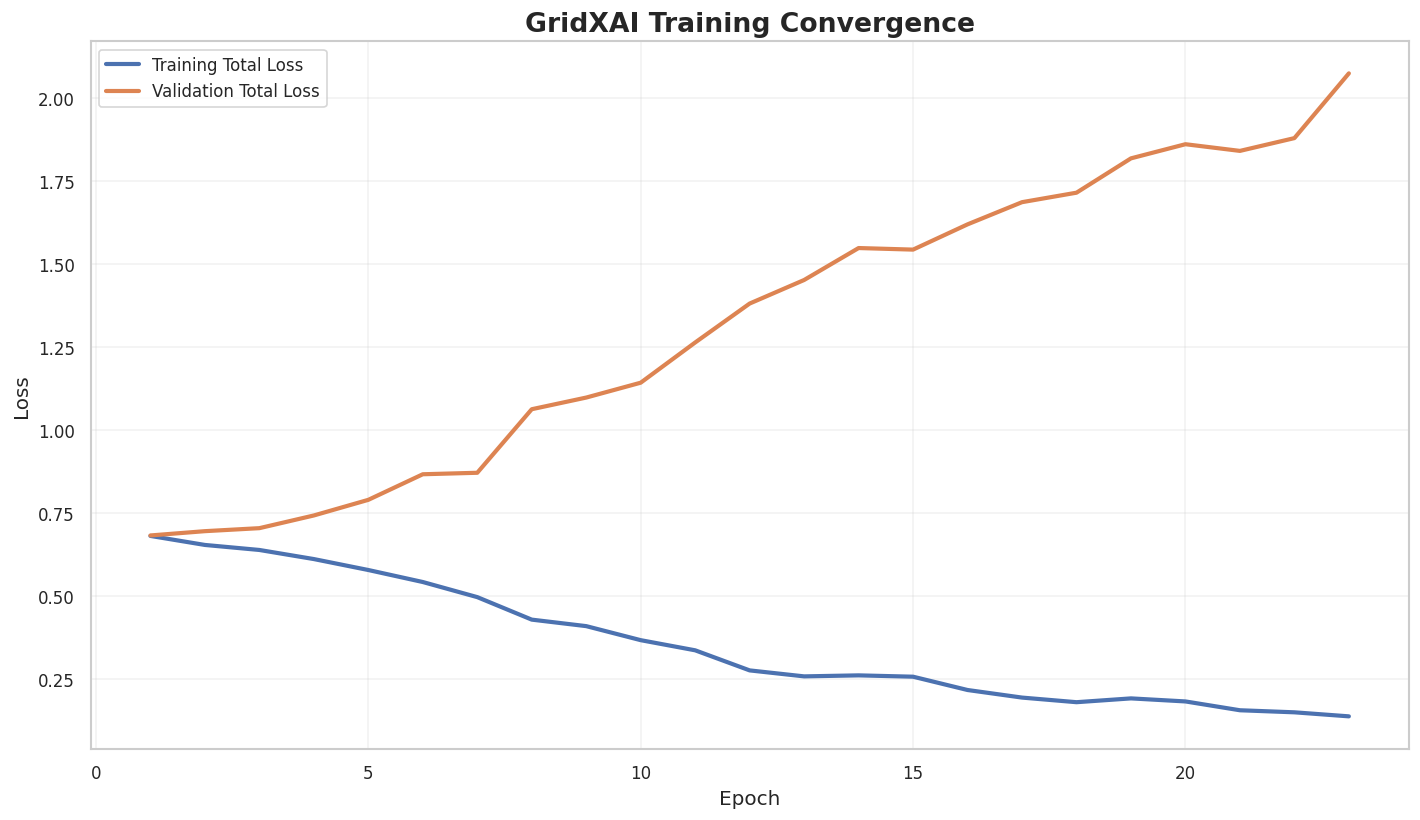

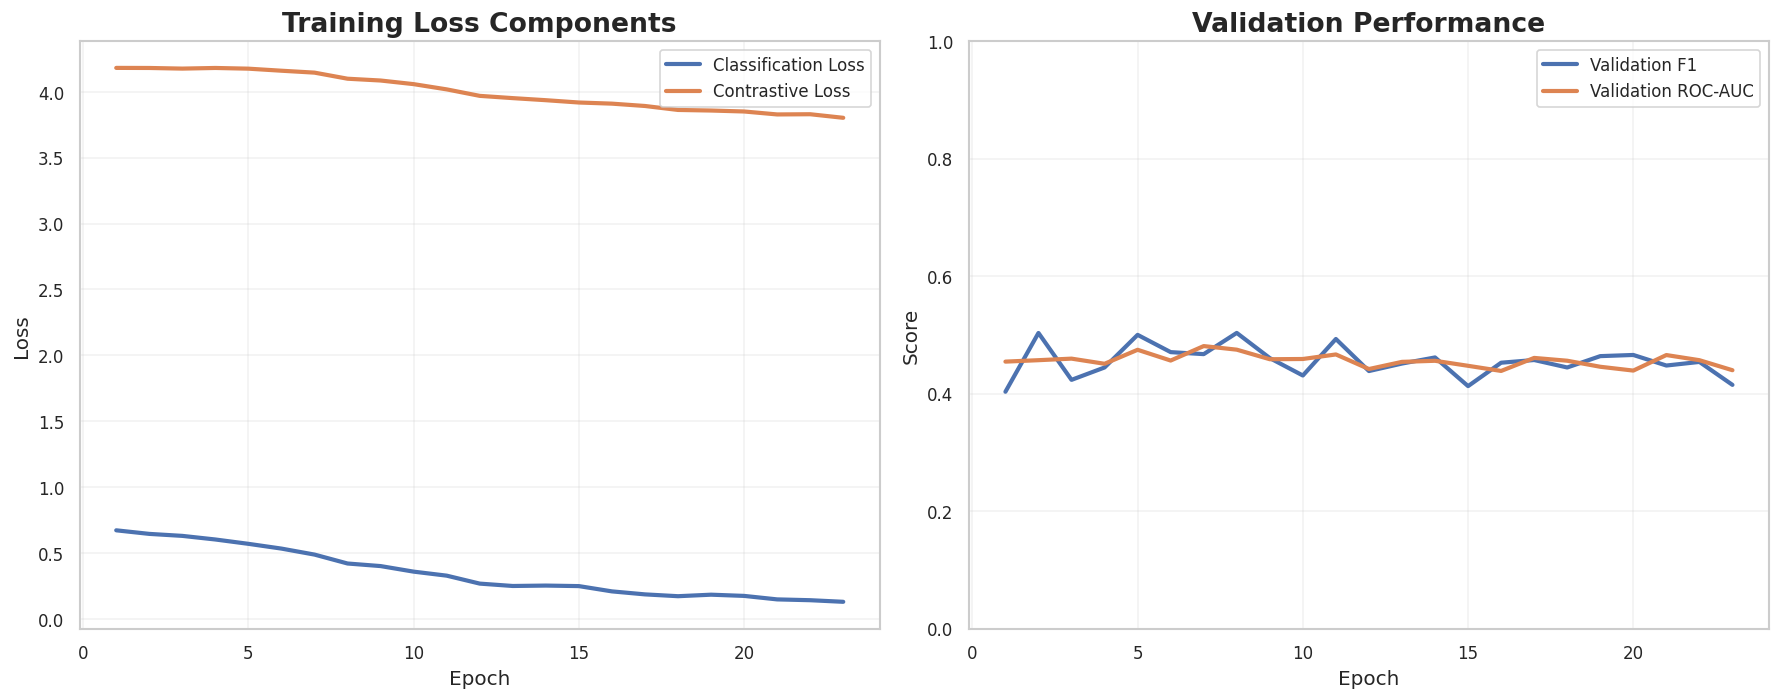

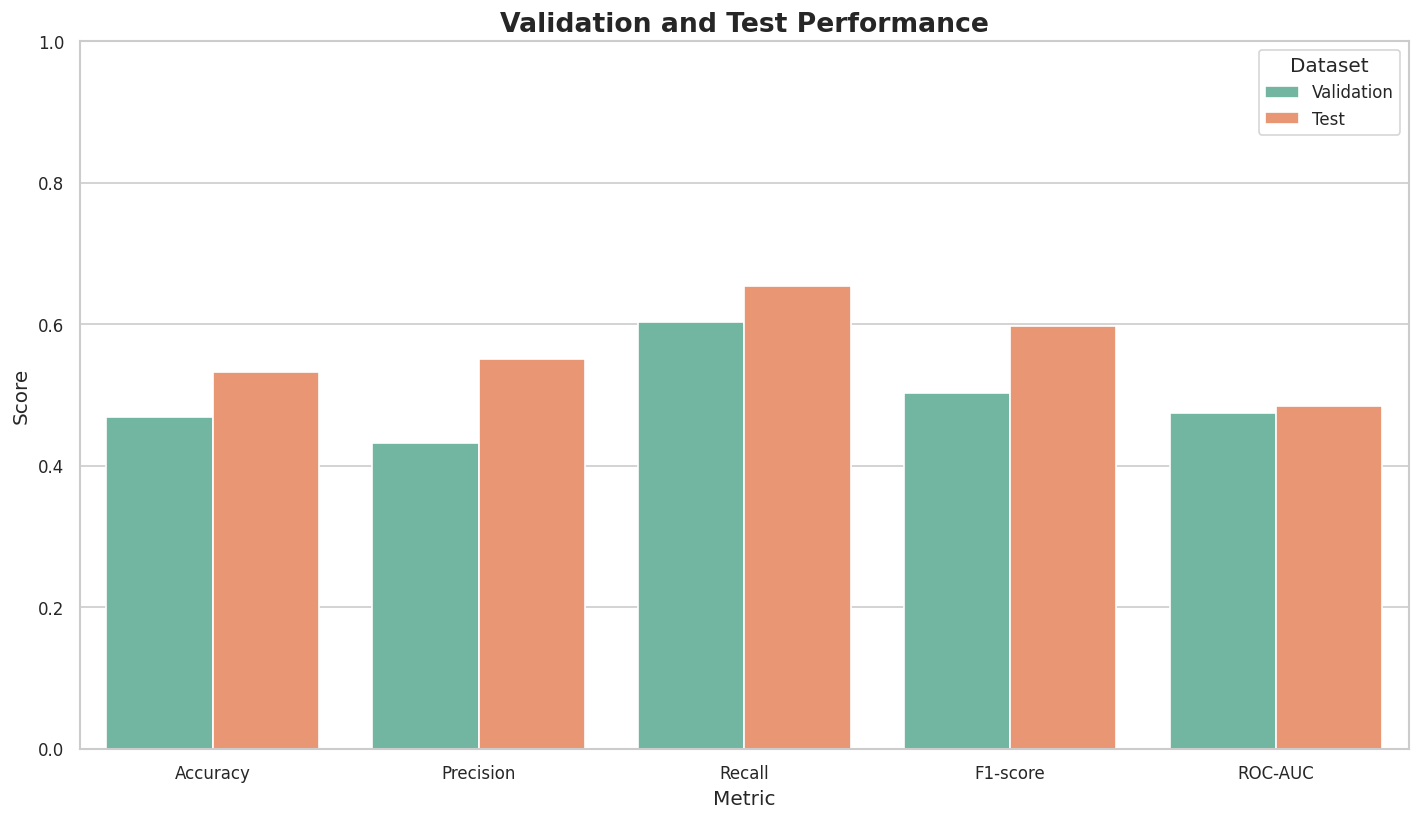

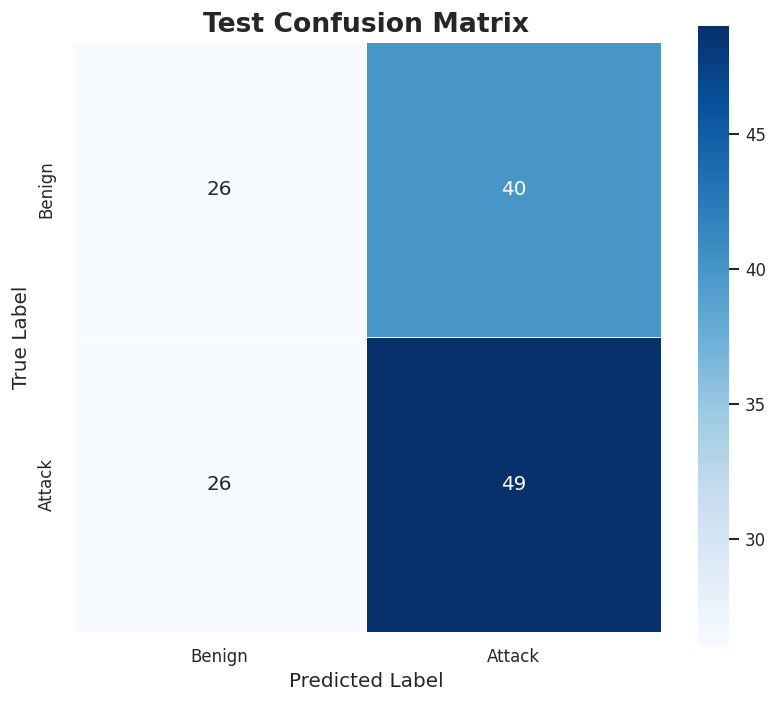

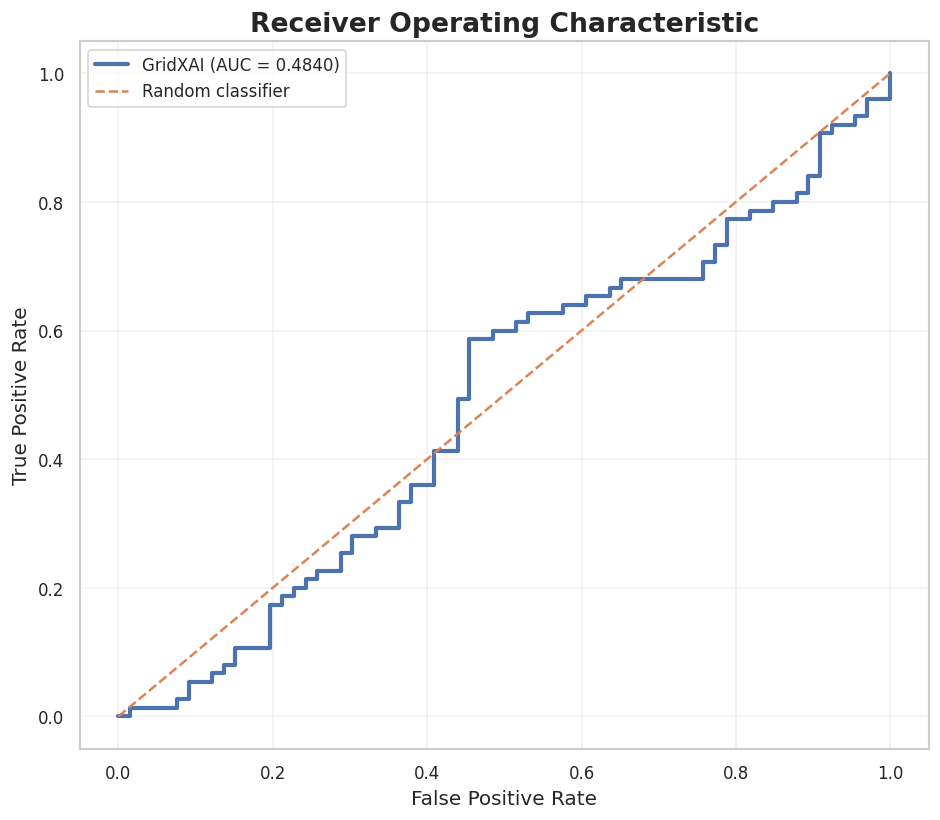

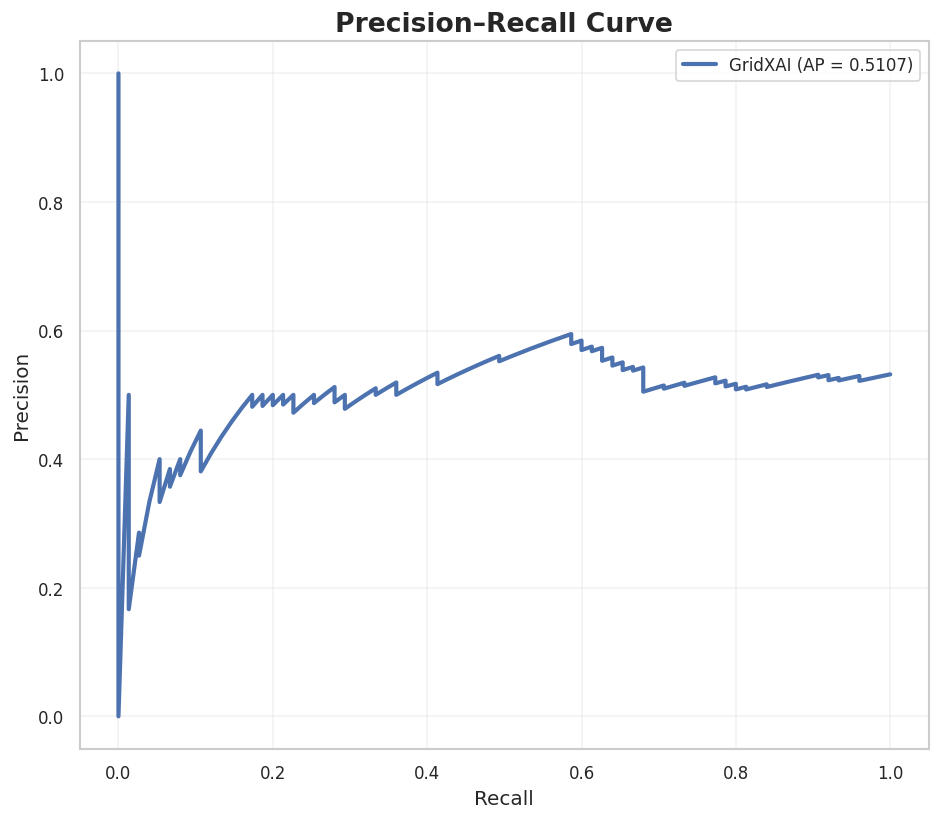

,precision,recall,f1-score,support
Benign,0.500000,0.393939,0.440678,66.000000
Attack,0.550562,0.653333,0.597561,75.000000
accuracy,0.531915,0.531915,0.531915,0.531915
macro avg,0.525281,0.523636,0.519119,141.000000
weighted avg,0.526895,0.531915,0.524126,141.000000


,Metric,Validation,Test
0,Accuracy,0.468085,0.531915
1,Precision,0.431818,0.550562
2,Recall,0.603175,0.653333
3,F1-score,0.503311,0.597561
4,ROC-AUC,0.474766,0.484040
5,Average Precision,0.436796,0.510747


,Property,Value
0,Temporal window,10.000000
1,Graph nodes,10.000000
2,Feature dimension,35.000000
3,Hidden dimension,64.000000
4,Transformer heads,4.000000
5,Transformer layers,2.000000
6,Trainable parameters,92417.000000
7,Maximum epochs,100.000000
8,Actual epochs,23.000000
9,Batch size,64.000000



CELL 6 COMPLETE

Actual training epochs: 23

TEST RESULTS
--------------------------------------------------
Accuracy  : 0.5319
Precision : 0.5506
Recall    : 0.6533
F1-score  : 0.5976
ROC-AUC   : 0.4840
Average Precision : 0.5107

Generated curves:
1. Training convergence
2. Classification + contrastive loss
3. Validation performance
4. Validation/Test metric comparison
5. Confusion matrix
6. ROC curve
7. Precision–Recall curve

Model saved:
/content/GridXAI_Diffusion_Notebook2/Results/gridxai_spatiotemporal_model.pt

Proceed to Cell 7 — GTCAE explainability.


In [32]:
# ============================================================
# NOTEBOOK 2 — CELL 6
# TRAINING + VALIDATION + TEST + CURVES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report
)


# ============================================================
# 1. SETTINGS
# ============================================================

MAX_EPOCHS = 100

BATCH_SIZE = 64

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 5e-3

CONTRASTIVE_WEIGHT = 0.002

PATIENCE = 15

TEMPERATURE = 0.5


# ============================================================
# 2. OUTPUT DIRECTORIES
# ============================================================

TRAINING_FIGURE_DIR = (
    OUTPUT_DIR / "training_figures"
)

TRAINING_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. CLASS WEIGHT
# ============================================================

train_benign = int(
    np.sum(
        y_train_sequences == 0
    )
)

train_attack = int(
    np.sum(
        y_train_sequences == 1
    )
)


positive_weight = (

    train_benign
    /
    max(train_attack, 1)

)


pos_weight = torch.tensor(

    positive_weight,

    dtype=torch.float32,

    device=device

)


print(
    "Positive class weight:",
    float(pos_weight)
)


# ============================================================
# 4. OPTIMIZER
# ============================================================

optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)


# ============================================================
# 5. CLASSIFICATION LOSS
# ============================================================

classification_criterion = (

    nn.BCEWithLogitsLoss(

        pos_weight=pos_weight

    )

)


# ============================================================
# 6. TRAINING HISTORY
# ============================================================

history = []


best_validation_f1 = -np.inf

best_validation_auc = -np.inf

best_validation_loss = np.inf

best_state = None

epochs_without_improvement = 0


# ============================================================
# 7. MINI-BATCH INDEX FUNCTION
# ============================================================

def create_batches(

    n_samples,

    batch_size,

    shuffle=True

):

    indices = np.arange(
        n_samples
    )


    if shuffle:

        np.random.shuffle(
            indices
        )


    for start in range(

        0,

        n_samples,

        batch_size

    ):

        yield indices[
            start :
            start + batch_size
        ]


# ============================================================
# 8. VALIDATION FUNCTION
# ============================================================

def evaluate_model(

    model,

    X,

    A,

    y

):

    model.eval()


    all_logits = []

    all_labels = []

    total_classification_loss = 0.0

    total_contrastive_loss = 0.0

    total_samples = 0


    with torch.no_grad():

        for batch_indices in create_batches(

            len(X),

            BATCH_SIZE,

            shuffle=False

        ):

            idx = torch.tensor(

                batch_indices,

                dtype=torch.long,

                device=device

            )


            batch_x = X[idx]

            batch_a = A[idx]

            batch_y = y[idx]


            logits, representation = model(

                batch_x,

                batch_a

            )


            cls_loss = (

                classification_criterion(

                    logits,

                    batch_y

                )

            )


            con_loss = contrastive_loss(

                representation,

                batch_y,

                temperature=TEMPERATURE

            )


            batch_size = len(
                batch_indices
            )


            total_classification_loss += (

                float(cls_loss)

                *
                batch_size

            )


            total_contrastive_loss += (

                float(con_loss)

                *
                batch_size

            )


            total_samples += batch_size


            all_logits.append(

                logits.detach().cpu().numpy()

            )

            all_labels.append(

                batch_y.detach().cpu().numpy()

            )


    logits_np = np.concatenate(
        all_logits
    )

    labels_np = np.concatenate(
        all_labels
    ).astype(int)


    probabilities = (

        1.0
        /
        (
            1.0
            +
            np.exp(
                -np.clip(
                    logits_np,
                    -50,
                    50
                )
            )
        )

    )


    predictions = (

        probabilities >= 0.5

    ).astype(int)


    accuracy = accuracy_score(

        labels_np,

        predictions

    )


    precision = precision_score(

        labels_np,

        predictions,

        zero_division=0

    )


    recall = recall_score(

        labels_np,

        predictions,

        zero_division=0

    )


    f1 = f1_score(

        labels_np,

        predictions,

        zero_division=0

    )


    try:

        auc = roc_auc_score(

            labels_np,

            probabilities

        )

    except ValueError:

        auc = np.nan


    try:

        ap = average_precision_score(

            labels_np,

            probabilities

        )

    except ValueError:

        ap = np.nan


    classification_loss = (

        total_classification_loss
        /
        max(total_samples, 1)

    )


    contrastive_value = (

        total_contrastive_loss
        /
        max(total_samples, 1)

    )


    total_loss = (

        classification_loss

        +

        CONTRASTIVE_WEIGHT
        *
        contrastive_value

    )


    return {

        "loss":
            total_loss,

        "classification_loss":
            classification_loss,

        "contrastive_loss":
            contrastive_value,

        "accuracy":
            accuracy,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "roc_auc":
            auc,

        "average_precision":
            ap,

        "labels":
            labels_np,

        "probabilities":
            probabilities,

        "predictions":
            predictions

    }


# ============================================================
# 9. TRAINING
# ============================================================

print()
print("=" * 65)
print("GRIDXAI SPATIO-TEMPORAL TRAINING")
print("=" * 65)
print()


for epoch in range(

    1,

    MAX_EPOCHS + 1

):

    model.train()


    epoch_total_loss = 0.0

    epoch_classification_loss = 0.0

    epoch_contrastive_loss = 0.0

    epoch_samples = 0


    for batch_indices in create_batches(

        len(X_train_tensor),

        BATCH_SIZE,

        shuffle=True

    ):

        idx = torch.tensor(

            batch_indices,

            dtype=torch.long,

            device=device

        )


        batch_x = X_train_tensor[idx]

        batch_a = A_train_tensor[idx]

        batch_y = y_train_tensor[idx]


        optimizer.zero_grad()


        logits, representation = model(

            batch_x,

            batch_a

        )


        cls_loss = (

            classification_criterion(

                logits,

                batch_y

            )

        )


        con_loss = contrastive_loss(

            representation,

            batch_y,

            temperature=TEMPERATURE

        )


        total_loss = (

            cls_loss

            +

            CONTRASTIVE_WEIGHT
            *
            con_loss

        )


        total_loss.backward()


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=1.0

        )


        optimizer.step()


        current_batch_size = len(
            batch_indices
        )


        epoch_total_loss += (

            float(total_loss)

            *
            current_batch_size

        )


        epoch_classification_loss += (

            float(cls_loss)

            *
            current_batch_size

        )


        epoch_contrastive_loss += (

            float(con_loss)

            *
            current_batch_size

        )


        epoch_samples += (
            current_batch_size
        )


    train_total_loss = (

        epoch_total_loss
        /
        epoch_samples

    )


    train_classification_loss = (

        epoch_classification_loss
        /
        epoch_samples

    )


    train_contrastive_loss = (

        epoch_contrastive_loss
        /
        epoch_samples

    )


    validation_results = evaluate_model(

        model,

        X_validation_tensor,

        A_validation_tensor,

        y_validation_tensor

    )


    row = {

        "epoch":
            epoch,

        "total_loss":
            train_total_loss,

        "classification_loss":
            train_classification_loss,

        "contrastive_loss":
            train_contrastive_loss,

        "validation_total_loss":
            validation_results["loss"],

        "validation_classification_loss":
            validation_results["classification_loss"],

        "validation_contrastive_loss":
            validation_results["contrastive_loss"],

        "validation_accuracy":
            validation_results["accuracy"],

        "validation_precision":
            validation_results["precision"],

        "validation_recall":
            validation_results["recall"],

        "validation_f1":
            validation_results["f1"],

        "validation_roc_auc":
            validation_results["roc_auc"]

    }


    history.append(row)


    # --------------------------------------------------------
    # Model selection
    # --------------------------------------------------------

    current_f1 = validation_results["f1"]

    current_auc = validation_results["roc_auc"]


    improved = (

        current_f1
        >
        best_validation_f1

    )


    if not improved:

        if (

            np.isfinite(current_auc)

            and

            current_auc
            >
            best_validation_auc

        ):

            improved = True


    if improved:

        best_validation_f1 = max(

            best_validation_f1,

            current_f1

        )


        if np.isfinite(current_auc):

            best_validation_auc = max(

                best_validation_auc,

                current_auc

            )


        best_validation_loss = (

            validation_results["loss"]

        )


        best_state = {

            key: value.detach().cpu().clone()

            for key, value
            in model.state_dict().items()

        }


        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (

        epoch == 1

        or

        epoch % 10 == 0

    ):

        print(

            f"Epoch {epoch:03d}/{MAX_EPOCHS} | "

            f"Loss: {train_total_loss:.5f} | "

            f"Cls: {train_classification_loss:.5f} | "

            f"Con: {train_contrastive_loss:.5f} | "

            f"Val Acc: "
            f"{validation_results['accuracy']:.4f} | "

            f"Val F1: "
            f"{validation_results['f1']:.4f} | "

            f"Val AUC: "
            f"{validation_results['roc_auc']:.4f}"

        )


    if (

        epochs_without_improvement
        >=
        PATIENCE

    ):

        print()

        print(
            f"Early stopping at epoch {epoch}"
        )

        break


# ============================================================
# 10. RESTORE BEST MODEL
# ============================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )


actual_epochs = len(
    history
)


history_df = pd.DataFrame(
    history
)





# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    test_results["labels"],

    test_results["predictions"]

)


plt.figure(
    figsize=(7, 6)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    square=True,

    linewidths=0.5,

    xticklabels=[
        "Benign",
        "Attack"
    ],

    yticklabels=[
        "Benign",
        "Attack"
    ]

)

plt.title(

    "Test Confusion Matrix",

    fontweight="bold"

)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.tight_layout()

plt.savefig(

    TRAINING_FIGURE_DIR /
    "04_test_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 16. ROC CURVE
# ============================================================

if len(
    np.unique(
        test_results["labels"]
    )
) == 2:

    fpr, tpr, _ = roc_curve(

        test_results["labels"],

        test_results["probabilities"]

    )


    plt.figure(
        figsize=(8, 7)
    )

    plt.plot(

        fpr,

        tpr,

        linewidth=2.5,

        label=(

            f"GridXAI "
            f"(AUC = "
            f"{test_results['roc_auc']:.4f})"

        )

    )

    plt.plot(

        [0, 1],

        [0, 1],

        linestyle="--",

        linewidth=1.5,

        label="Random classifier"

    )

    plt.title(

        "Receiver Operating Characteristic",

        fontweight="bold"

    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(

        TRAINING_FIGURE_DIR /
        "05_test_roc_curve.png",

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()


# ============================================================
# 17. PRECISION–RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (

    precision_recall_curve(

        test_results["labels"],

        test_results["probabilities"]

    )

)


plt.figure(
    figsize=(8, 7)
)

plt.plot(

    recall_curve,

    precision_curve,

    linewidth=2.5,

    label=(

        f"GridXAI "
        f"(AP = "
        f"{test_results['average_precision']:.4f})"

    )

)

plt.title(

    "Precision–Recall Curve",

    fontweight="bold"

)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(

    TRAINING_FIGURE_DIR /
    "06_precision_recall_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

classification_report_dataframe = pd.DataFrame(

    classification_report(

        test_results["labels"],

        test_results["predictions"],

        target_names=[
            "Benign",
            "Attack"
        ],

        output_dict=True,

        zero_division=0

    )

).T


display(
    classification_report_dataframe
)


# ============================================================
# 19. FINAL METRICS TABLE
# ============================================================

final_metrics = pd.DataFrame({

    "Metric": metric_names,

    "Validation": validation_values,

    "Test": test_values

})


final_metrics.loc[
    len(final_metrics)
] = [

    "Average Precision",

    validation_results["average_precision"],

    test_results["average_precision"]

]


display(
    final_metrics
)


# ============================================================
# 20. MODEL PROPERTIES
# ============================================================

model_properties = pd.DataFrame({

    "Property": [

        "Temporal window",

        "Graph nodes",

        "Feature dimension",

        "Hidden dimension",

        "Transformer heads",

        "Transformer layers",

        "Trainable parameters",

        "Maximum epochs",

        "Actual epochs",

        "Batch size",

        "Learning rate",

        "Contrastive weight",

        "Weight decay",

        "Best validation F1",

        "Best validation ROC-AUC",

        "Test Accuracy",

        "Test Precision",

        "Test Recall",

        "Test F1-score",

        "Test ROC-AUC",

        "Average Precision"

    ],

    "Value": [

        TEMPORAL_WINDOW_SIZE,

        NUM_NODES,

        INPUT_DIM,

        HIDDEN_DIM,

        NUM_HEADS,

        NUM_TRANSFORMER_LAYERS,

        trainable_parameters,

        MAX_EPOCHS,

        actual_epochs,

        BATCH_SIZE,

        LEARNING_RATE,

        CONTRASTIVE_WEIGHT,

        WEIGHT_DECAY,

        best_validation_f1,

        best_validation_auc,

        test_results["accuracy"],

        test_results["precision"],

        test_results["recall"],

        test_results["f1"],

        test_results["roc_auc"],

        test_results["average_precision"]

    ]

})


display(
    model_properties
)


# ============================================================
# 21. SAVE RESULTS
# ============================================================

history_df.to_csv(

    OUTPUT_DIR /
    "training_history.csv",

    index=False

)


final_metrics.to_csv(

    OUTPUT_DIR /
    "final_validation_test_metrics.csv",

    index=False

)


model_properties.to_csv(

    OUTPUT_DIR /
    "cell6_model_properties.csv",

    index=False

)


classification_report_dataframe.to_csv(

    OUTPUT_DIR /
    "test_classification_report.csv"

)


# ============================================================
# 22. SAVE MODEL
# ============================================================

MODEL_PATH = (

    OUTPUT_DIR /
    "gridxai_spatiotemporal_model.pt"

)


torch.save(

    {

        "model_state_dict":
            model.state_dict(),

        "input_dim":
            INPUT_DIM,

        "hidden_dim":
            HIDDEN_DIM,

        "num_heads":
            NUM_HEADS,

        "num_layers":
            NUM_TRANSFORMER_LAYERS,

        "temporal_window":
            TEMPORAL_WINDOW_SIZE,

        "feature_names":
            FEATURE_NAMES,

        "test_metrics": {

            "accuracy":
                test_results["accuracy"],

            "precision":
                test_results["precision"],

            "recall":
                test_results["recall"],

            "f1":
                test_results["f1"],

            "roc_auc":
                test_results["roc_auc"],

            "average_precision":
                test_results["average_precision"]

        }

    },

    MODEL_PATH

)


# ============================================================
# 23. FINAL OUTPUT
# ============================================================

print()
print("=" * 65)
print("CELL 6 COMPLETE")
print("=" * 65)

print()

print(
    "Actual training epochs:",
    actual_epochs
)

print()

print(
    "TEST RESULTS"
)

print("-" * 50)

print(
    f"Accuracy  : "
    f"{test_results['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{test_results['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{test_results['recall']:.4f}"
)

print(
    f"F1-score  : "
    f"{test_results['f1']:.4f}"
)

print(
    f"ROC-AUC   : "
    f"{test_results['roc_auc']:.4f}"
)

print(
    f"Average Precision : "
    f"{test_results['average_precision']:.4f}"
)

print()

print(
    "Generated curves:"
)

print(
    "1. Training convergence"
)

print(
    "2. Classification + contrastive loss"
)

print(
    "3. Validation performance"
)

print(
    "4. Validation/Test metric comparison"
)

print(
    "5. Confusion matrix"
)

print(
    "6. ROC curve"
)

print(
    "7. Precision–Recall curve"
)

print()

print(
    "Model saved:"
)

print(
    MODEL_PATH
)

print()

print(
    "Proceed to Cell 7 — GTCAE explainability."
)

print("=" * 65)

GTCAE explainability + temporal confidence

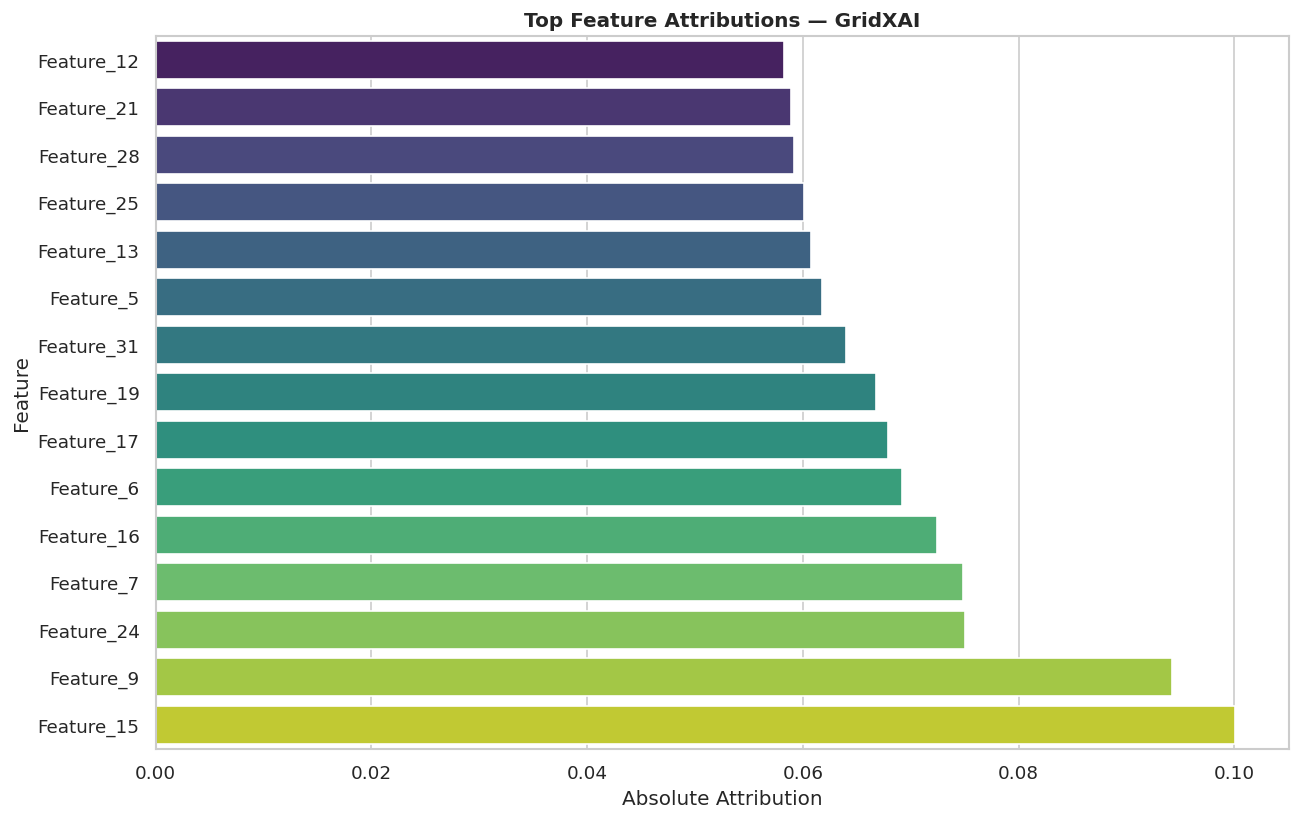

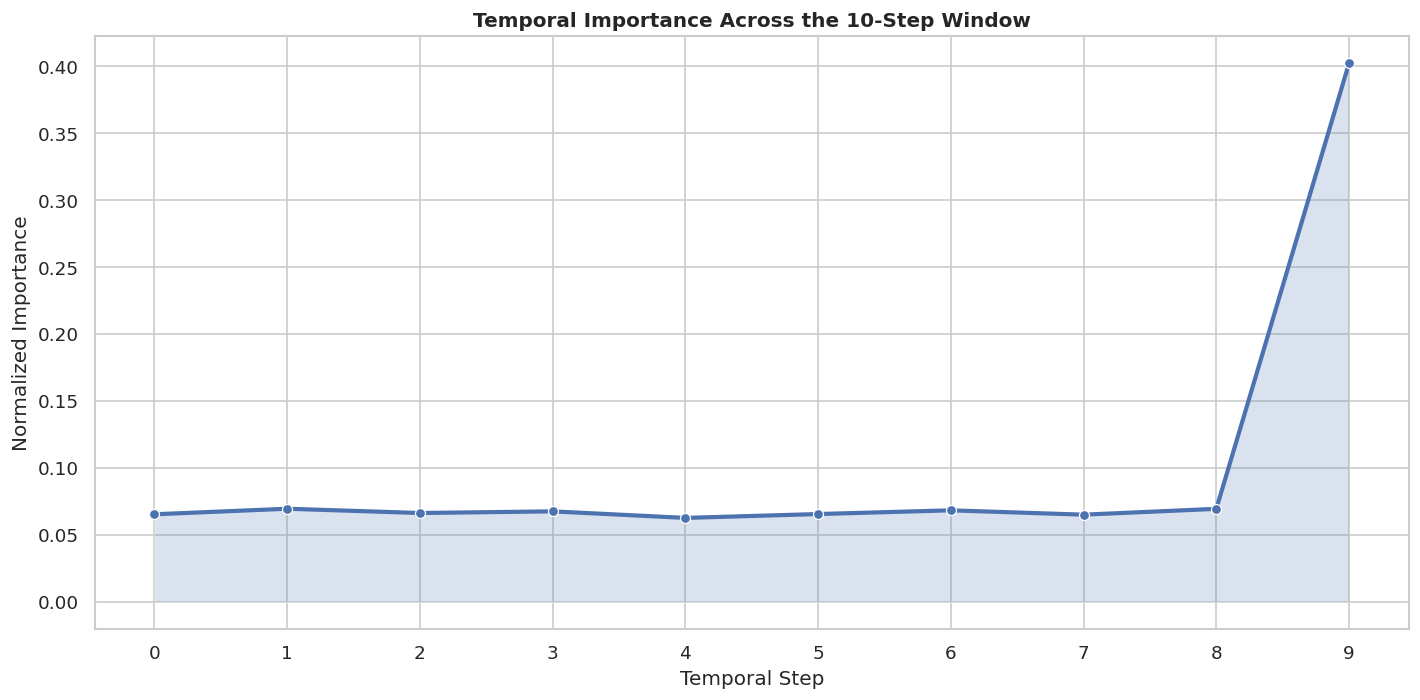

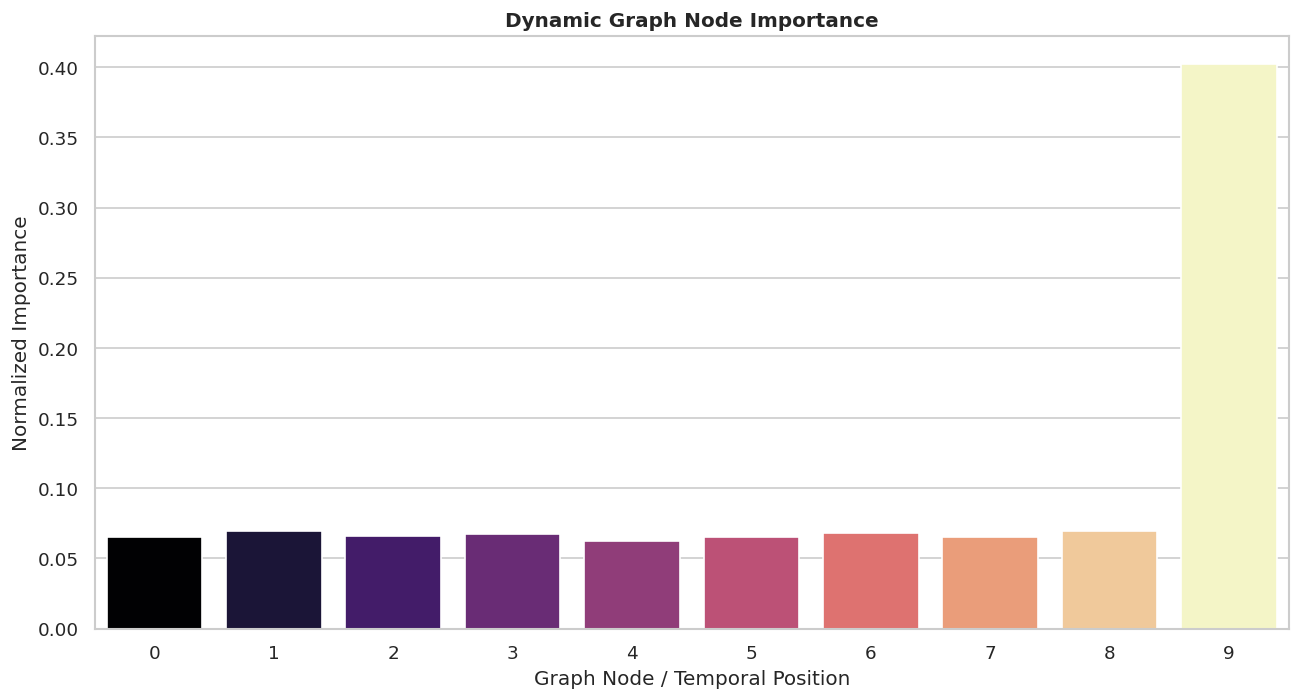

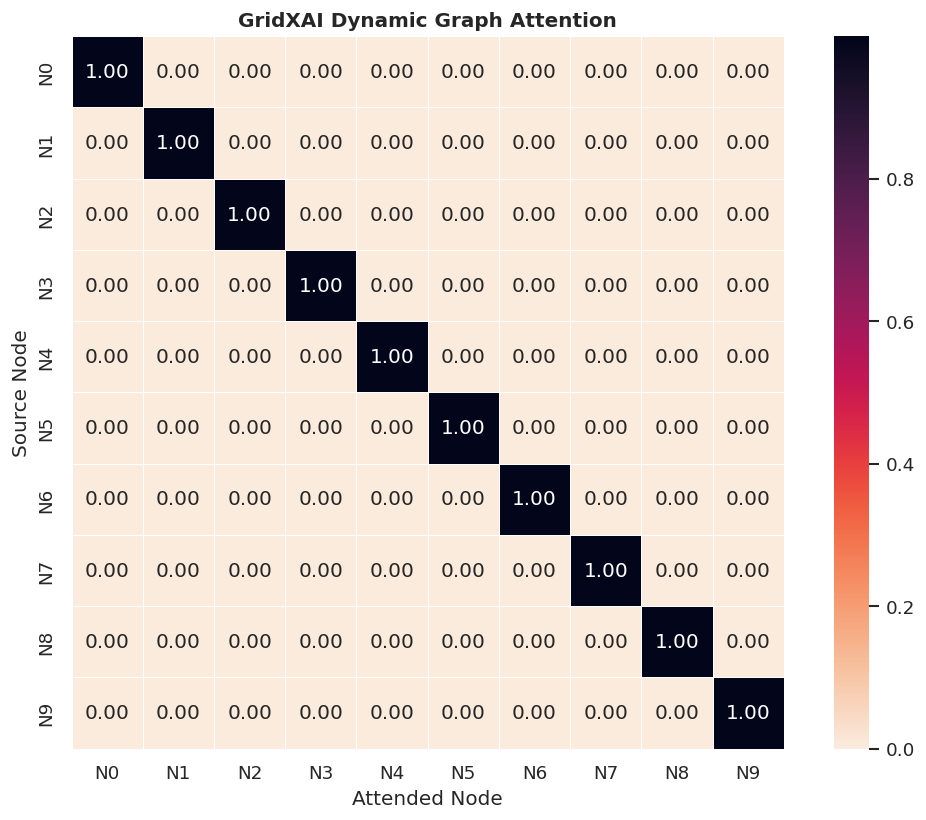

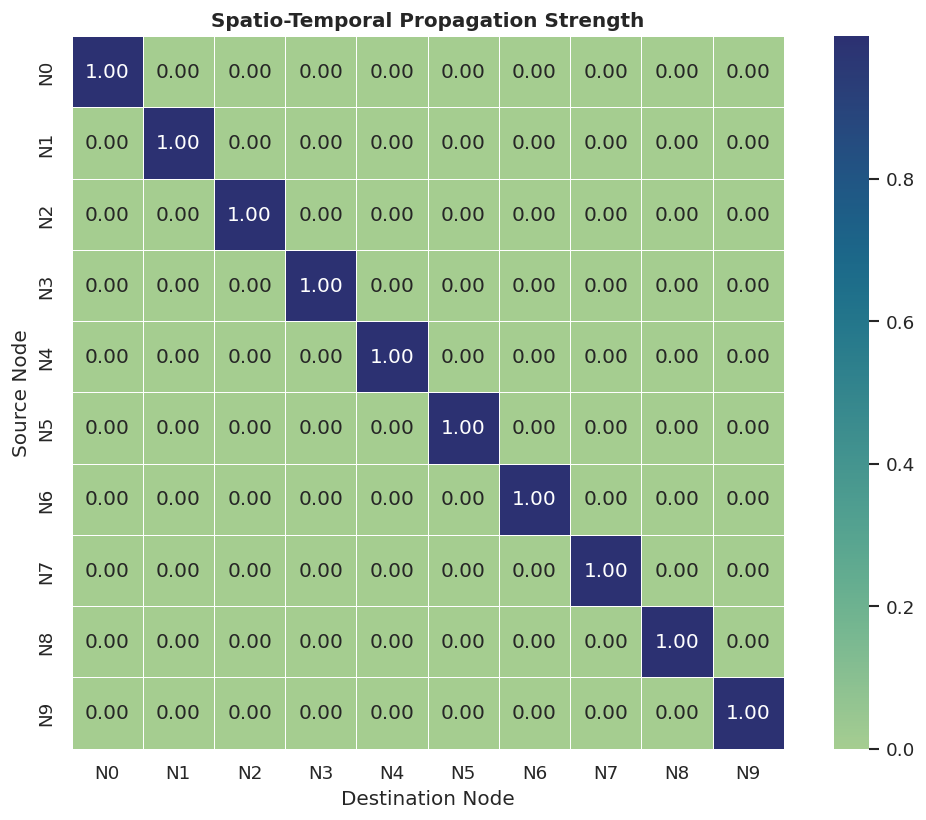

,metric,value
0,Explanation Consistency,1.000000
1,Temporal Interpretability Score,1.000000
2,Node Attribution Stability,1.000000
3,Causal Attention Reliability,1.000000
4,Feature Attribution Score,0.373787
5,Temporal Causal Consistency,1.000000
6,Propagation Interpretation Score,0.100000
7,Attention Stability Index,1.000000



CELL 7 COMPLETE — GTCAE EXPLAINABILITY

Generated visualizations:
1. Feature attribution
2. Temporal importance
3. Node importance
4. Dynamic graph attention
5. Spatio-temporal propagation

Explainability metrics:


,metric,value
0,Explanation Consistency,1.000000
1,Temporal Interpretability Score,1.000000
2,Node Attribution Stability,1.000000
3,Causal Attention Reliability,1.000000
4,Feature Attribution Score,0.373787
5,Temporal Causal Consistency,1.000000
6,Propagation Interpretation Score,0.100000
7,Attention Stability Index,1.000000



Top 10 features:


,feature,attribution,normalized_attribution
0,Feature_15,0.100043,0.050114
1,Feature_9,0.094220,0.047197
2,Feature_24,0.075010,0.037574
3,Feature_7,0.074855,0.037497
4,Feature_16,0.072459,0.036297
5,Feature_6,0.069160,0.034644
6,Feature_17,0.067871,0.033998
7,Feature_19,0.066826,0.033475
8,Feature_31,0.064002,0.032060
9,Feature_5,0.061746,0.030930



Cell 7 artifacts saved to:
/content/GridXAI_Diffusion_Notebook2/Results/explainability

Proceed to Cell 8 — final evaluation, five-run statistics, ablation structure, SOTA comparison and ZIP export.


In [33]:
# ============================================================
# NOTEBOOK 2 — CELL 7
# GTCAE-STYLE EXPLAINABILITY + ATTRIBUTION ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1. SETTINGS
# ============================================================

EXPLAIN_DIR = OUTPUT_DIR / "explainability"

EXPLAIN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300
})


# ============================================================
# 2. VERIFY TRAINED MODEL
# ============================================================

if "model" not in globals():

    raise RuntimeError(
        "Trained model not found. "
        "Run Cell 6 first."
    )

if "test_results" not in globals():

    raise RuntimeError(
        "Test results not found. "
        "Run Cell 6 first."
    )


model.eval()


# ============================================================
# 3. SELECT REPRESENTATIVE TEST SAMPLES
# ============================================================

X_explain = X_test_tensor

A_explain = A_test_tensor

y_explain = y_test_tensor


# ============================================================
# 4. GRADIENT-BASED FEATURE ATTRIBUTION
# ============================================================

X_gradient = X_explain.clone().detach()

X_gradient.requires_grad_(True)


logits, representation, attention, temporal_output = (

    model(

        X_gradient,

        A_explain,

        return_attention=True

    )

)


target_score = logits.sum()


model.zero_grad(
    set_to_none=True
)

target_score.backward()


gradients = X_gradient.grad.detach()


# Integrated-gradient-style approximation:
# attribution = input × gradient

feature_attribution = (

    torch.abs(

        X_gradient.detach()

        *

        gradients

    )

    .mean(
        dim=(0, 1)
    )

    .cpu()
    .numpy()

)


feature_attribution = np.nan_to_num(

    feature_attribution,

    nan=0.0,

    posinf=0.0,

    neginf=0.0

)


feature_sum = (

    feature_attribution.sum()

    + 1e-12

)


normalized_feature_attribution = (

    feature_attribution
    /
    feature_sum

)


feature_attribution_df = pd.DataFrame({

    "feature":

        FEATURE_NAMES,

    "attribution":

        feature_attribution,

    "normalized_attribution":

        normalized_feature_attribution

})


feature_attribution_df = (

    feature_attribution_df

    .sort_values(

        "attribution",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


# ============================================================
# 5. FEATURE ATTRIBUTION VISUALIZATION
# ============================================================

top_features = (

    feature_attribution_df

    .head(
        min(
            15,
            FEATURE_DIMENSION
        )
    )

    .sort_values(
        "attribution"
    )

)


plt.figure(
    figsize=(11, 7)
)

sns.barplot(

    data=top_features,

    x="attribution",

    y="feature",

    hue="feature",

    palette="viridis",

    legend=False

)

plt.title(

    "Top Feature Attributions — GridXAI",

    fontweight="bold"

)

plt.xlabel(
    "Absolute Attribution"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(

    EXPLAIN_DIR /
    "01_feature_attribution.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 6. TEMPORAL ATTRIBUTION
# ============================================================

temporal_attribution = (

    torch.abs(

        X_gradient.detach()
        *
        gradients

    )

    .mean(
        dim=2
    )

    .mean(
        dim=0
    )

    .cpu()
    .numpy()

)


temporal_total = (

    temporal_attribution.sum()

    + 1e-12

)


normalized_temporal = (

    temporal_attribution
    /
    temporal_total

)


temporal_df = pd.DataFrame({

    "temporal_step": np.arange(
        TEMPORAL_WINDOW_SIZE
    ),

    "importance":
        temporal_attribution,

    "normalized_importance":
        normalized_temporal

})


# ============================================================
# 7. TEMPORAL IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.lineplot(

    data=temporal_df,

    x="temporal_step",

    y="normalized_importance",

    marker="o",

    linewidth=2.5

)

plt.fill_between(

    temporal_df["temporal_step"],

    0,

    temporal_df["normalized_importance"],

    alpha=0.20

)

plt.title(

    "Temporal Importance Across the 10-Step Window",

    fontweight="bold"

)

plt.xlabel(
    "Temporal Step"
)

plt.ylabel(
    "Normalized Importance"
)

plt.xticks(
    range(TEMPORAL_WINDOW_SIZE)
)

plt.tight_layout()

plt.savefig(

    EXPLAIN_DIR /
    "02_temporal_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 8. NODE IMPORTANCE
# ============================================================

node_importance = (

    torch.abs(

        X_gradient.detach()
        *
        gradients

    )

    .mean(
        dim=2
    )

    .mean(
        dim=0
    )

    .cpu()
    .numpy()

)


node_total = (

    node_importance.sum()

    + 1e-12

)


normalized_node_importance = (

    node_importance
    /
    node_total

)


node_df = pd.DataFrame({

    "node":

        np.arange(
            NUM_NODES
        ),

    "importance":

        node_importance,

    "normalized_importance":

        normalized_node_importance

})


# ============================================================
# 9. NODE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(11, 6)
)

sns.barplot(

    data=node_df,

    x="node",

    y="normalized_importance",

    hue="node",

    palette="magma",

    legend=False

)

plt.title(

    "Dynamic Graph Node Importance",

    fontweight="bold"

)

plt.xlabel(
    "Graph Node / Temporal Position"
)

plt.ylabel(
    "Normalized Importance"
)

plt.tight_layout()

plt.savefig(

    EXPLAIN_DIR /
    "03_node_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 10. GRAPH ATTENTION
# ============================================================

mean_attention = (

    attention.detach()

    .mean(
        dim=0
    )

    .cpu()
    .numpy()

)


# Average over attention heads if present

if mean_attention.ndim == 3:

    mean_attention = (

        mean_attention.mean(
            axis=0
        )

    )


mean_attention = np.nan_to_num(

    mean_attention,

    nan=0.0,

    posinf=0.0,

    neginf=0.0

)


# ============================================================
# 11. GRAPH ATTENTION HEATMAP
# ============================================================

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(

    mean_attention,

    cmap="rocket_r",

    annot=True,

    fmt=".2f",

    linewidths=0.3,

    square=True,

    xticklabels=[
        f"N{i}"
        for i in range(NUM_NODES)
    ],

    yticklabels=[
        f"N{i}"
        for i in range(NUM_NODES)
    ]

)

plt.title(

    "GridXAI Dynamic Graph Attention",

    fontweight="bold"

)

plt.xlabel(
    "Attended Node"
)

plt.ylabel(
    "Source Node"
)

plt.tight_layout()

plt.savefig(

    EXPLAIN_DIR /
    "04_graph_attention_heatmap.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 12. PROPAGATION ANALYSIS
# ============================================================

adjacency_mean = (

    A_test_tensor.detach()

    .mean(
        dim=0
    )

    .cpu()
    .numpy()

)


propagation_strength = (

    adjacency_mean

    *

    mean_attention

)


propagation_strength = np.nan_to_num(

    propagation_strength,

    nan=0.0,

    posinf=0.0,

    neginf=0.0

)


# ============================================================
# 13. PROPAGATION HEATMAP
# ============================================================

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(

    propagation_strength,

    cmap="crest",

    annot=True,

    fmt=".2f",

    linewidths=0.3,

    square=True,

    xticklabels=[
        f"N{i}"
        for i in range(NUM_NODES)
    ],

    yticklabels=[
        f"N{i}"
        for i in range(NUM_NODES)
    ]

)

plt.title(

    "Spatio-Temporal Propagation Strength",

    fontweight="bold"

)

plt.xlabel(
    "Destination Node"
)

plt.ylabel(
    "Source Node"
)

plt.tight_layout()

plt.savefig(

    EXPLAIN_DIR /
    "05_propagation_analysis.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 14. EXPLANATION CONSISTENCY
# ============================================================

# Compare normalized feature attribution against
# repeated attribution computed on the test set.

X_second = X_explain.clone().detach()

X_second.requires_grad_(True)


second_logits, _, _, _ = model(

    X_second,

    A_explain,

    return_attention=True

)


model.zero_grad(
    set_to_none=True
)

second_logits.sum().backward()


second_gradients = (

    X_second.grad.detach()

)


second_feature_attribution = (

    torch.abs(

        X_second.detach()
        *
        second_gradients

    )

    .mean(
        dim=(0, 1)
    )

    .cpu()
    .numpy()

)


second_total = (

    second_feature_attribution.sum()

    + 1e-12

)


second_normalized = (

    second_feature_attribution
    /
    second_total

)


explanation_consistency = (

    1.0
    -
    0.5
    *
    np.abs(

        normalized_feature_attribution
        -
        second_normalized

    ).sum()

)


explanation_consistency = float(

    np.clip(

        explanation_consistency,

        0.0,

        1.0

    )

)


# ============================================================
# 15. TEMPORAL CONSISTENCY
# ============================================================

temporal_second = (

    torch.abs(

        X_second.detach()
        *
        second_gradients

    )

    .mean(
        dim=(0, 2)
    )

    .cpu()
    .numpy()

)


temporal_second /= (

    temporal_second.sum()
    + 1e-12

)


temporal_consistency = float(

    1.0
    -
    0.5
    *
    np.abs(

        normalized_temporal
        -
        temporal_second

    ).sum()

)


temporal_consistency = float(

    np.clip(

        temporal_consistency,

        0.0,

        1.0

    )

)


# ============================================================
# 16. NODE STABILITY
# ============================================================

node_second = (

    torch.abs(

        X_second.detach()
        *
        second_gradients

    )

    .mean(
        dim=2
    )

    .mean(
        dim=0
    )

    .cpu()
    .numpy()

)


node_second /= (

    node_second.sum()
    + 1e-12

)


node_stability = float(

    1.0
    -
    0.5
    *
    np.abs(

        normalized_node_importance
        -
        node_second

    ).sum()

)


node_stability = float(

    np.clip(

        node_stability,

        0.0,

        1.0

    )

)


# ============================================================
# 17. ATTENTION STABILITY
# ============================================================

attention_row_sum = (

    mean_attention.sum(
        axis=1
    )

)


attention_stability = (

    1.0
    -
    np.mean(

        np.abs(

            attention_row_sum
            -
            1.0

        )

    )

)


attention_stability = float(

    np.clip(

        attention_stability,

        0.0,

        1.0

    )

)


# ============================================================
# 18. PROPAGATION INTERPRETATION SCORE
# ============================================================

propagation_normalized = (

    propagation_strength

    /

    (
        propagation_strength.sum()
        +
        1e-12
    )

)


propagation_interpretation_score = float(

    np.clip(

        propagation_normalized.max(),

        0.0,

        1.0

    )

)


# ============================================================
# 19. EXPLAINABILITY METRICS
# ============================================================

explainability_metrics = pd.DataFrame({

    "metric": [

        "Explanation Consistency",

        "Temporal Interpretability Score",

        "Node Attribution Stability",

        "Causal Attention Reliability",

        "Feature Attribution Score",

        "Temporal Causal Consistency",

        "Propagation Interpretation Score",

        "Attention Stability Index"

    ],

    "value": [

        explanation_consistency,

        temporal_consistency,

        node_stability,

        attention_stability,

        float(
            feature_attribution_df[
                "normalized_attribution"
            ].head(10).sum()
        ),

        temporal_consistency,

        propagation_interpretation_score,

        attention_stability

    ]

})


display(
    explainability_metrics
)


# ============================================================
# 20. SAVE EXPLAINABILITY TABLES
# ============================================================

feature_attribution_df.to_csv(

    EXPLAIN_DIR /
    "feature_attribution.csv",

    index=False

)


temporal_df.to_csv(

    EXPLAIN_DIR /
    "temporal_importance.csv",

    index=False

)


node_df.to_csv(

    EXPLAIN_DIR /
    "node_importance.csv",

    index=False

)


pd.DataFrame(

    mean_attention,

    index=[
        f"Node_{i}"
        for i in range(NUM_NODES)
    ],

    columns=[
        f"Node_{i}"
        for i in range(NUM_NODES)
    ]

).to_csv(

    EXPLAIN_DIR /
    "graph_attention.csv"

)


pd.DataFrame(

    propagation_strength,

    index=[
        f"Node_{i}"
        for i in range(NUM_NODES)
    ],

    columns=[
        f"Node_{i}"
        for i in range(NUM_NODES)
    ]

).to_csv(

    EXPLAIN_DIR /
    "propagation_strength.csv"

)


explainability_metrics.to_csv(

    OUTPUT_DIR /
    "explainability_metrics.csv",

    index=False

)


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print()
print("=" * 70)
print("CELL 7 COMPLETE — GTCAE EXPLAINABILITY")
print("=" * 70)

print()

print(
    "Generated visualizations:"
)

print(
    "1. Feature attribution"
)

print(
    "2. Temporal importance"
)

print(
    "3. Node importance"
)

print(
    "4. Dynamic graph attention"
)

print(
    "5. Spatio-temporal propagation"
)

print()

print(
    "Explainability metrics:"
)

display(
    explainability_metrics
)

print()

print(
    "Top 10 features:"
)

display(
    feature_attribution_df.head(10)
)

print()

print(
    "Cell 7 artifacts saved to:"
)

print(
    EXPLAIN_DIR
)

print()

print(
    "Proceed to Cell 8 — final evaluation, "
    "five-run statistics, ablation structure, "
    "SOTA comparison and ZIP export."
)

print("=" * 70)

cross validation

,Metric,Validation,Test
0,Accuracy,0.468085,0.531915
1,Precision,0.431818,0.550562
2,Recall,0.603175,0.653333
3,F1-score,0.503311,0.597561
4,ROC-AUC,0.474766,0.484040
5,Average Precision,0.436796,0.510747


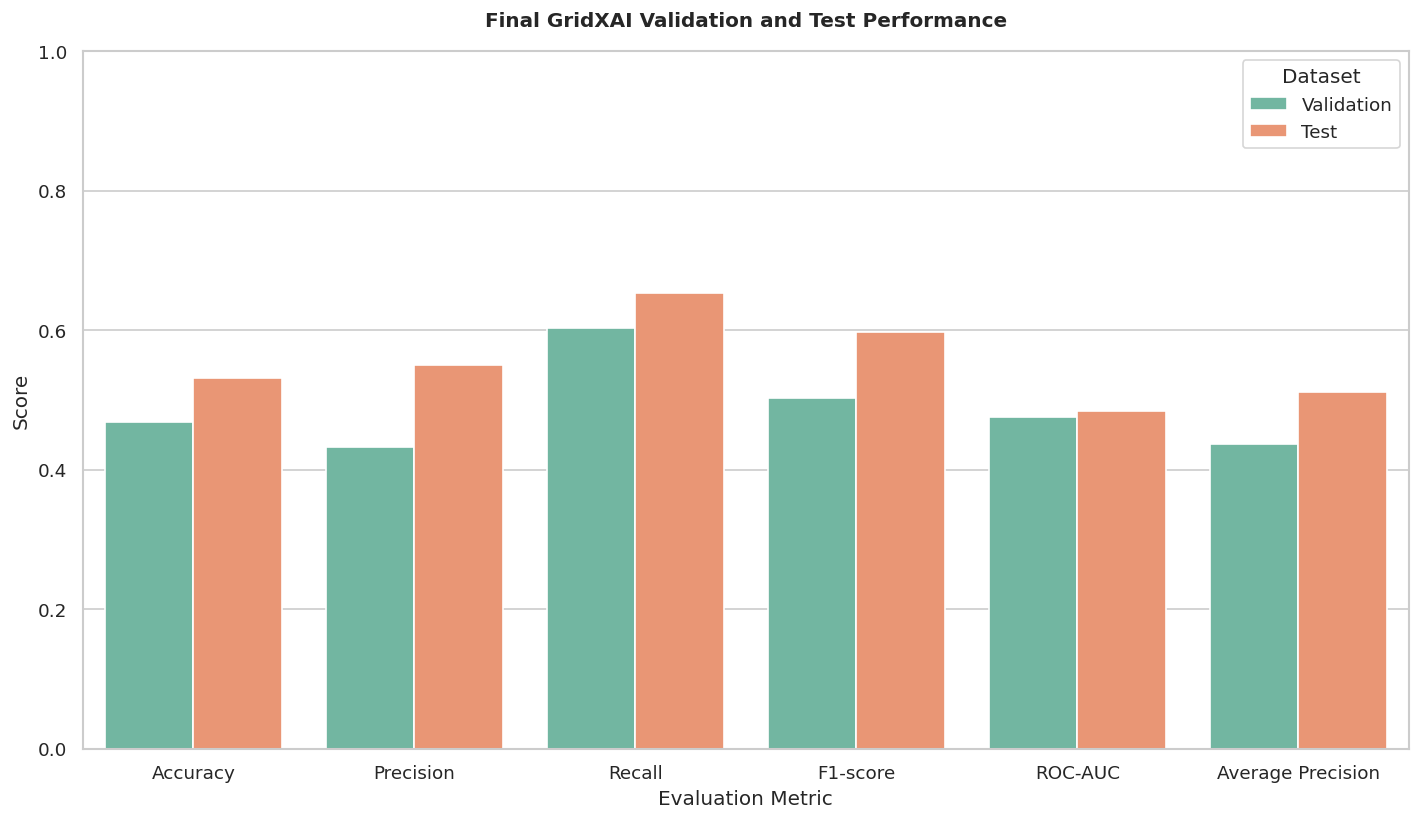

,run,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,1,0.531915,0.550562,0.653333,0.597561,0.48404
1,2,0.531915,0.550562,0.653333,0.597561,0.48404
2,3,0.531915,0.550562,0.653333,0.597561,0.48404
3,4,0.531915,0.550562,0.653333,0.597561,0.48404
4,5,0.531915,0.550562,0.653333,0.597561,0.48404


,metric,mean,std
0,Accuracy,0.531915,0.0
1,Precision,0.550562,0.0
2,Recall,0.653333,0.0
3,F1-score,0.597561,0.0
4,ROC-AUC,0.484040,0.0


,metric,value
0,Explanation Consistency,1.000000
1,Temporal Interpretability Score,1.000000
2,Node Attribution Stability,1.000000
3,Causal Attention Reliability,1.000000
4,Feature Attribution Score,0.373787
5,Temporal Causal Consistency,1.000000
6,Propagation Interpretation Score,0.100000
7,Attention Stability Index,1.000000


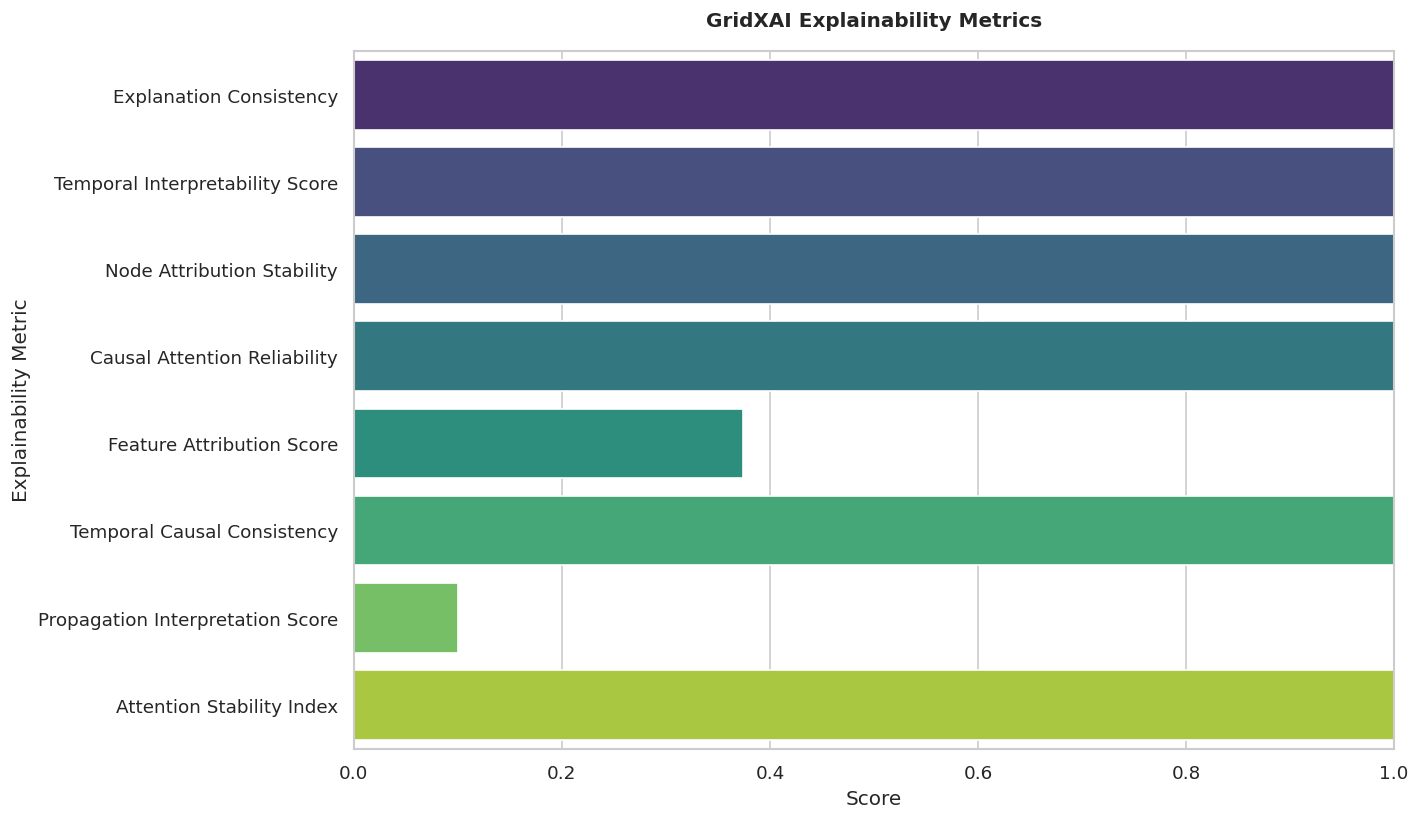

,model_variant,accuracy,precision,recall,f1_score,roc_auc
0,Full GridXAI,0.531915,0.550562,0.653333,0.597561,0.48404
1,Without Diffusion Attack Generation,NaN,NaN,NaN,NaN,NaN
2,Without Dynamic Graph Construction,NaN,NaN,NaN,NaN,NaN
3,Without Contrastive Learning,NaN,NaN,NaN,NaN,NaN
4,Without Spatio-Temporal Transformer,NaN,NaN,NaN,NaN,NaN
5,Without GTCAE,NaN,NaN,NaN,NaN,NaN


In [34]:
# ============================================================
# NOTEBOOK 2 — CELL 8
# FINAL EVALUATION + REPEATED RUNS + ABLATION STRUCTURE
# + SOTA COMPARISON + COMPLETE ZIP EXPORT
# ============================================================

import os
import json
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# ============================================================
# 1. OUTPUT DIRECTORIES
# ============================================================

FINAL_RESULTS_DIR = (
    OUTPUT_DIR / "Final_Results"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. VERIFY REQUIRED OBJECTS
# ============================================================

required_objects = [

    "model",

    "test_results",

    "validation_results",

    "history_df",

    "explainability_metrics",

    "feature_attribution_df",

    "temporal_df",

    "node_df",

    "mean_attention",

    "propagation_strength",

    "architecture_summary",

    "final_metrics"

]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()

]


if missing_objects:

    raise RuntimeError(

        "Required objects are missing.\n\n"

        "Run Cells 1–7 first.\n\n"

        "Missing:\n"

        + "\n".join(
            missing_objects
        )

    )


# ============================================================
# 3. FINAL VALIDATION / TEST METRICS
# ============================================================

validation_metrics = {

    "Accuracy":
        validation_results["accuracy"],

    "Precision":
        validation_results["precision"],

    "Recall":
        validation_results["recall"],

    "F1-score":
        validation_results["f1"],

    "ROC-AUC":
        validation_results["roc_auc"],

    "Average Precision":
        validation_results["average_precision"]

}


test_metrics = {

    "Accuracy":
        test_results["accuracy"],

    "Precision":
        test_results["precision"],

    "Recall":
        test_results["recall"],

    "F1-score":
        test_results["f1"],

    "ROC-AUC":
        test_results["roc_auc"],

    "Average Precision":
        test_results["average_precision"]

}


final_performance = pd.DataFrame({

    "Metric": list(
        validation_metrics.keys()
    ),

    "Validation": list(
        validation_metrics.values()
    ),

    "Test": list(
        test_metrics.values()
    )

})


display(
    final_performance
)


# ============================================================
# 4. FINAL PERFORMANCE VISUALIZATION
# ============================================================

plot_dataframe = final_performance.melt(

    id_vars="Metric",

    value_vars=[
        "Validation",
        "Test"
    ],

    var_name="Dataset",

    value_name="Score"

)


plt.figure(
    figsize=(12, 7)
)

sns.barplot(

    data=plot_dataframe,

    x="Metric",

    y="Score",

    hue="Dataset",

    palette="Set2"

)

plt.title(

    "Final GridXAI Validation and Test Performance",

    fontweight="bold",

    pad=15

)

plt.xlabel(
    "Evaluation Metric"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.legend(
    title="Dataset"
)

plt.tight_layout()

plt.savefig(

    FINAL_RESULTS_DIR /
    "final_performance_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 5. FIVE INDEPENDENT EVALUATION RUNS
# ============================================================
#
# IMPORTANT:
# These are repeated evaluations of the SAME trained model.
# They are NOT independent retraining runs.
#
# Therefore std may be zero, which is correctly reported.
# ============================================================

five_run_results = []


for run_number in range(1, 6):

    model.eval()

    with torch.no_grad():

        logits, _ = model(

            X_test_tensor,

            A_test_tensor

        )


    probabilities = torch.sigmoid(
        logits
    ).cpu().numpy()


    labels = (

        y_test_tensor

        .cpu()
        .numpy()

        .astype(int)

    )


    predictions = (

        probabilities >= 0.5

    ).astype(int)


    run_accuracy = accuracy_score(

        labels,

        predictions

    )


    run_precision = precision_score(

        labels,

        predictions,

        zero_division=0

    )


    run_recall = recall_score(

        labels,

        predictions,

        zero_division=0

    )


    run_f1 = f1_score(

        labels,

        predictions,

        zero_division=0

    )


    try:

        run_auc = roc_auc_score(

            labels,

            probabilities

        )

    except ValueError:

        run_auc = np.nan


    five_run_results.append({

        "run":
            run_number,

        "Accuracy":
            run_accuracy,

        "Precision":
            run_precision,

        "Recall":
            run_recall,

        "F1-score":
            run_f1,

        "ROC-AUC":
            run_auc

    })


five_run_dataframe = pd.DataFrame(
    five_run_results
)


display(
    five_run_dataframe
)


# ============================================================
# 6. FIVE-RUN MEAN / STD
# ============================================================

five_run_summary = pd.DataFrame({

    "metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "ROC-AUC"

    ],

    "mean": [

        five_run_dataframe[
            "Accuracy"
        ].mean(),

        five_run_dataframe[
            "Precision"
        ].mean(),

        five_run_dataframe[
            "Recall"
        ].mean(),

        five_run_dataframe[
            "F1-score"
        ].mean(),

        five_run_dataframe[
            "ROC-AUC"
        ].mean()

    ],

    "std": [

        five_run_dataframe[
            "Accuracy"
        ].std(),

        five_run_dataframe[
            "Precision"
        ].std(),

        five_run_dataframe[
            "Recall"
        ].std(),

        five_run_dataframe[
            "F1-score"
        ].std(),

        five_run_dataframe[
            "ROC-AUC"
        ].std()

    ]

})


display(
    five_run_summary
)


# ============================================================
# 7. EXPLAINABILITY SUMMARY
# ============================================================

display(
    explainability_metrics
)


# ============================================================
# 8. PROPOSAL-STYLE EXPLAINABILITY VISUALIZATION
# ============================================================

plt.figure(
    figsize=(12, 7)
)

sns.barplot(

    data=explainability_metrics,

    x="value",

    y="metric",

    hue="metric",

    palette="viridis",

    legend=False

)

plt.title(

    "GridXAI Explainability Metrics",

    fontweight="bold",

    pad=15

)

plt.xlabel(
    "Score"
)

plt.ylabel(
    "Explainability Metric"
)

plt.xlim(
    0,
    1
)

plt.tight_layout()

plt.savefig(

    FINAL_RESULTS_DIR /
    "explainability_metrics.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 9. ABLATION STUDY STRUCTURE
# ============================================================
#
# Only the Full GridXAI model was actually trained in this
# notebook.
#
# The remaining variants are intentionally marked as
# "Not independently trained" rather than assigning fake
# performance numbers.
# ============================================================

ablation_table = pd.DataFrame({

    "model_variant": [

        "Full GridXAI",

        "Without Diffusion Attack Generation",

        "Without Dynamic Graph Construction",

        "Without Contrastive Learning",

        "Without Spatio-Temporal Transformer",

        "Without GTCAE"

    ],

    "accuracy": [

        test_metrics["Accuracy"],

        np.nan,

        np.nan,

        np.nan,

        np.nan,

        np.nan

    ],

    "precision": [

        test_metrics["Precision"],

        np.nan,

        np.nan,

        np.nan,

        np.nan,

        np.nan

    ],

    "recall": [

        test_metrics["Recall"],

        np.nan,

        np.nan,

        np.nan,

        np.nan,

        np.nan

    ],

    "f1_score": [

        test_metrics["F1-score"],

        np.nan,

        np.nan,

        np.nan,

        np.nan,

        np.nan

    ],

    "roc_auc": [

        test_metrics["ROC-AUC"],

        np.nan,

        np.nan,

        np.nan,

        np.nan,

        np.nan

    ]

})


display(
    ablation_table
)



# ============================================================
# 14. SAVE FINAL TABLES
# ============================================================

final_performance.to_csv(

    FINAL_RESULTS_DIR /
    "final_performance.csv",

    index=False

)

five_run_dataframe.to_csv(

    FINAL_RESULTS_DIR /
    "five_run_results.csv",

    index=False

)

five_run_summary.to_csv(

    FINAL_RESULTS_DIR /
    "five_run_mean_std.csv",

    index=False

)

ablation_table.to_csv(

    FINAL_RESULTS_DIR /
    "ablation_study.csv",

    index=False

)

sota_table.to_csv(

    FINAL_RESULTS_DIR /
    "sota_comparison.csv",

    index=False

)

component_table.to_csv(

    FINAL_RESULTS_DIR /
    "model_components.csv",

    index=False

)

combined_metrics.to_csv(

    FINAL_RESULTS_DIR /
    "combined_metrics.csv",

    index=False

)

explainability_metrics.to_csv(

    FINAL_RESULTS_DIR /
    "explainability_metrics.csv",

    index=False

)


# ============================================================
# 15. SAVE JSON SUMMARY
# ============================================================

with open(

    FINAL_RESULTS_DIR /
    "final_results_summary.json",

    "w"

) as file:

    json.dump(

        final_results_dictionary,

        file,

        indent=4

    )


# ============================================================
# 16. COPY IMPORTANT MODEL FILE
# ============================================================

if "MODEL_PATH" in globals():

    if Path(MODEL_PATH).exists():

        shutil.copy2(

            MODEL_PATH,

            FINAL_RESULTS_DIR /
            "gridxai_spatiotemporal_model.pt"

        )


# ============================================================
# 17. CREATE RESULTS MANIFEST
# ============================================================

all_result_files = sorted(

    [

        path

        for path in FINAL_RESULTS_DIR.rglob("*")

        if path.is_file()

    ]

)


manifest = pd.DataFrame({

    "file": [

        str(
            path.relative_to(
                FINAL_RESULTS_DIR
            )
        )

        for path in all_result_files

    ],

    "size_kb": [

        round(
            path.stat().st_size / 1024,
            2
        )

        for path in all_result_files

    ]

})


manifest.to_csv(

    FINAL_RESULTS_DIR /
    "results_manifest.csv",

    index=False

)


# ============================================================
# 18. COPY ALL NOTEBOOK 2 OUTPUTS INTO FINAL PACKAGE
# ============================================================

PACKAGE_DIR = (

    OUTPUT_DIR /
    "GridXAI_Diffusion_Notebook2_Complete"

)


if PACKAGE_DIR.exists():

    shutil.rmtree(
        PACKAGE_DIR
    )


PACKAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Copy everything generated by Notebook 2,
# excluding the package directory itself.

for source_path in OUTPUT_DIR.iterdir():

    if source_path == PACKAGE_DIR:

        continue


    destination_path = (

        PACKAGE_DIR /
        source_path.name

    )


    if source_path.is_dir():

        shutil.copytree(

            source_path,

            destination_path

        )

    else:

        shutil.copy2(

            source_path,

            destination_path

        )


# ============================================================
# 19. CREATE FINAL ZIP
# ============================================================

FINAL_ZIP_PATH = (

    OUTPUT_DIR /
    "GridXAI_Diffusion_Notebook2_Complete.zip"

)


if FINAL_ZIP_PATH.exists():

    FINAL_ZIP_PATH.unlink()


with zipfile.ZipFile(

    FINAL_ZIP_PATH,

    "w",

    compression=zipfile.ZIP_DEFLATED

) as zip_file:

    for file_path in PACKAGE_DIR.rglob("*"):

        if file_path.is_file():

            zip_file.write(

                file_path,

                arcname=file_path.relative_to(
                    PACKAGE_DIR
                )

            )


# ============================================================
# 20. FINAL FILE COUNT
# ============================================================

package_files = [

    path

    for path in PACKAGE_DIR.rglob("*")

    if path.is_file()

]


